In [1]:
import numpy as np
import glob,os
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.mpl.ticker as cticker
from cartopy.feature.nightshade import Nightshade
from datetime import datetime, date,timedelta
import xarray as xr
import matplotlib.gridspec as gridspec
import scipy.io as sio
import imageio.v2 as imageio
import re
from cartopy.util import add_cyclic_point
from collections import defaultdict
from cmcrameri import cm
from scipy.interpolate import interp1d
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter,LongitudeLocator,LatitudeLocator
import time
import matplotlib as mpl
from cartopy.feature.nightshade import Nightshade
import matplotlib.dates as mdates
import matplotlib.image as mpimg
import seaborn as sns
from skimage.metrics import structural_similarity as ssim


In [2]:
def doy_to_month_day(year, doy):
    # Create a date object for the given year and DOY
    date = datetime(year, 1, 1) + timedelta(days=doy - 1)
    
    # Extract the month and day
    month = date.month
    day = date.day
    
    return month, day

def decimal_hours_to_hms(hh1):
    # Get whole hours
    hh = int(hh1)
    
    # Get minutes from the fractional part
    mm, remainder = divmod((hh1 - hh) * 3600, 60)
    mm = int(mm)
    
    # Get seconds from the remainder and round to nearest integer
    ss = round(remainder)
    
    # Handle the case where seconds round to 60
    if ss == 60:
        ss = 0
        mm += 1
        if mm == 60:
            mm = 0
            hh += 1
    
    return hh, mm, ss


def parse_map(tecmap, exponent = -1):
    tecmap = re.split('.*END OF TEC MAP', tecmap)[0]
    return np.stack([np.fromstring(l, sep=' ') for l in re.split('.*LAT/LON1/LON2/DLON/H\\n',tecmap)[1:]])*10**exponent
    
def get_tecmaps(filename):
    with open(filename) as f:
        ionex = f.read()
        return [parse_map(t) for t in ionex.split('START OF TEC MAP')[1:]]
    


In [3]:
yr=2024
yr1=yr%100
dstfile='kp_dst.txt'
dst_ut=np.arange(24*4)

with open(dstfile,'r') as f:text=f.readlines()
dstdata=np.zeros([len(text),5])
for i in range(len(text)):
    data=np.array(text[i].split())
    dstdata[i,0]=int(data[0])
    dstdata[i,1]=int(data[1])
    dstdata[i,2]=int(data[2])
    dstdata[i,3]=int(data[3])/10#kp
    dstdata[i,4]=int(data[4])#dst


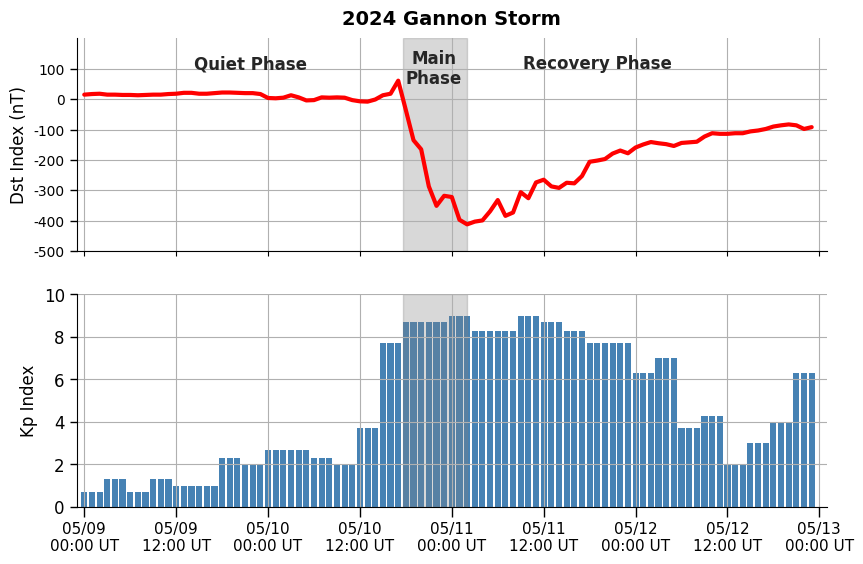

In [4]:
dst_ut = np.arange(24 * 4)


# Define the storm phase markers in hours
main_ph = 26 + 24
quiet_ph = 24 + 17 + 40 / 60

# Create a figure with two subplots, sharing the x-axis
fig, (ax_dst, ax_kp) = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(9, 6),
    dpi=100
)
plt.style.use('seaborn-v0_8-white') # Use a style without a grid

# --- 1. Top Subplot: Kp Index ---
ax_kp.bar(dst_ut, dstdata[:, 3], color='steelblue', label='Kp')
ax_kp.set_ylim(0, 10)
#ax_kp.plot([main_ph, main_ph], [0, 15], '--k', linewidth=2.5)
#ax_kp.plot([quiet_ph, quiet_ph], [0, 15], '--k', linewidth=2.5)

ax_kp.axvspan(quiet_ph, main_ph, color='gray', alpha=0.3)

# Y-axis for Kp
ax_kp.set_yticks(np.arange(0, 11, 2))
ax_kp.set_yticklabels(np.arange(0, 11, 2), color='k', fontsize=12)
ax_kp.set_ylabel('Kp Index', color='k', fontsize=12)
#ax_kp.set_title('2024 Gannon Storm', fontsize=14, pad=10)
ax_kp.tick_params(axis='y', which='both', length=5, width=1)
ax_kp.spines['top'].set_visible(False)
ax_kp.spines['right'].set_visible(False)
ax_kp.grid()

# --- 2. Bottom Subplot: Dst Index ---
ax_dst.plot(dst_ut, dstdata[:, 4], '-',color='red', linewidth=3, label='Dst')
ax_dst.set_xlim(-1, 24 * 4 + 1)
ax_dst.set_ylim(-500, 200)
#ax_dst.plot([main_ph, main_ph], [-500, 100], '--k', linewidth=2.5)
#ax_dst.plot([quiet_ph, quiet_ph], [-500, 100], '--k', linewidth=2.5)
ax_dst.axvspan(quiet_ph, main_ph, color='grey', alpha=0.3)

ax_dst.set_title('2024 Gannon Storm', fontsize=14, pad=10,fontweight='bold')
ax_dst.text(quiet_ph - 20, 100, 'Quiet Phase', fontsize=12, ha='center', fontweight='bold')
ax_dst.text(quiet_ph + 4, 50, 'Main\nPhase', fontsize=12, ha='center', fontweight='bold')
ax_dst.text(main_ph + 17, 100, 'Recovery Phase', fontsize=12, ha='center', fontweight='bold')

# Y-axis for Dst
ax_dst.set_yticks(np.arange(-500, 200, 100))
ax_dst.set_yticklabels(np.arange(-500, 200, 100), color='k')
ax_dst.set_ylabel('Dst Index (nT)', color='k', fontsize=12)
ax_dst.tick_params(axis='y', which='both', length=5, width=1)
ax_dst.spines['top'].set_visible(False)
ax_dst.spines['right'].set_visible(False)
ax_dst.grid()
# --- Shared X-axis Formatting ---
start_date = datetime(2024, 5, 9)
# Generate a complete list of dates for accurate labeling
dates = [start_date + timedelta(hours=int(h)) for h in dst_ut]
tick_locations = np.arange(0, 4 * 24 + 1, 12) # Tick every 12 hours
ax_kp.set_xticks(tick_locations)

# Create labels corresponding to the tick locations
xtick_labels = [(start_date + timedelta(hours=int(h))).strftime('%m/%d\n%H:%M UT') for h in tick_locations]
ax_kp.set_xticklabels(xtick_labels, rotation=0, ha='center', fontsize=11)
ax_kp.tick_params(axis='x', which='both', length=7, width=1)

# Adjust spacing between subplots
plt.tight_layout(pad=2.0)

# Display the plot
plt.show()


In [5]:
yr=2024
yr1=yr%100
doy1=130
#model='GloTEC'

cmap1=plt.get_cmap('viridis',30)
cmap2=cm.vik

print(cm.__file__)

/home/mchou1/.local/lib/python3.10/site-packages/cmcrameri/cm.py


# Load TEC and TEC RMSE data


In [6]:
all_data = np.load('TEC_rmse_UTLAT_map.npz', allow_pickle=True)
#model_data = all_data['model_data'].item()
RMSE_UTLAT=all_data['RMSE_UTLAT'].item()
TEC_UTLAT=all_data['TEC_UTLAT'].item()
model_latidx=all_data['model_latidx']

# TEC RMSE maps  as a function of UT and latitude

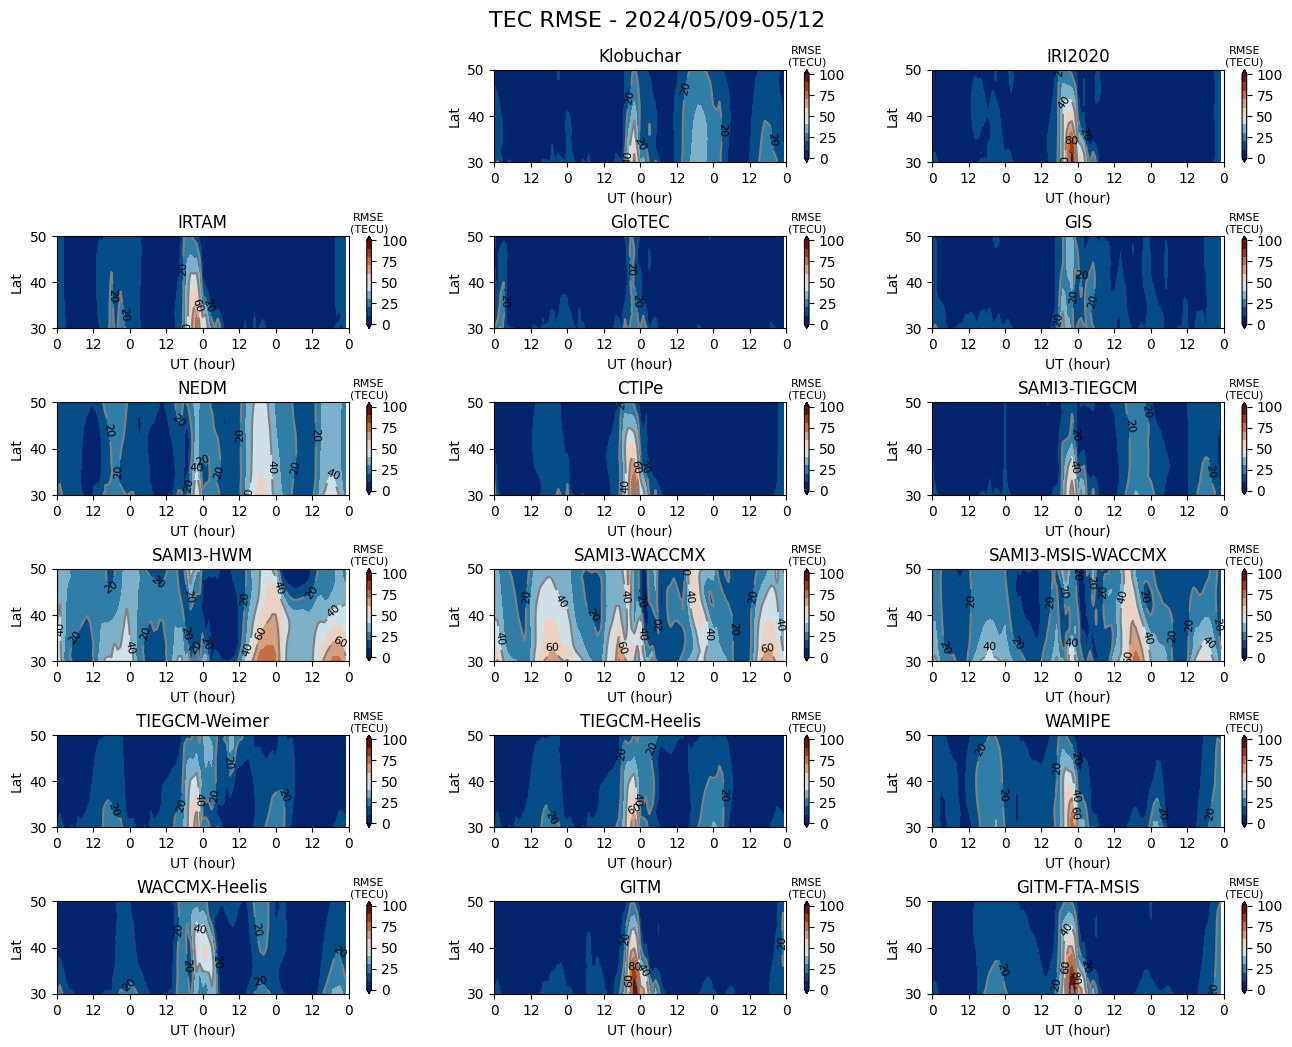

In [9]:
models=['Klobuchar','IRI2020','IRTAM','GloTEC','GIS','NEDM','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX','SAMI3-MSIS-WACCMX',
        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Heelis','GITM','GITM-FTA-MSIS']
plt.style.use('default')
            #gs=fig.add_gridspec(2,3)
fig,(axs)=plt.subplots(6,3,dpi=100)
fig.set_size_inches(16, 12)
plt.subplots_adjust(hspace = .8)
level=np.arange(0,105,10)
for model, ax in zip(models,axs.ravel()[1:]):
    #cntr1=ax.pcolor(np.arange(0,3*24,1),model_latidx,(TEC_UTLAT[model]-TEC_UTLAT['Madrigal TEC']),vmin=-20,vmax=20,cmap=cmap2);
    cntr1=ax.contourf(np.arange(0,4*24,1),model_latidx, RMSE_UTLAT[model],levels=level,cmap=cmap2,extend='both');
    #ccc=ax.contour(x,y,err1,levels=[-50,-25, 0, 25, 50],colors='black')
    ccc=ax.contour(np.arange(0,4*24,1),model_latidx, RMSE_UTLAT[model],levels=np.arange(0,101,20),colors='gray');
    plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'black')
    if model=='MadTEC':
        ax.set_title(f'Madrigal TEC') #75-125W
    else:
        ax.set_title(f'{model}') #75-125W
    clb=fig.colorbar(cntr1,ax=ax,ticks=np.arange(0,101,25))
    ax.set_xticks(np.arange(0,4*24+1,12))
    ax.set_xticklabels(np.mod(np.arange(0,4*24+1,12),24))
    ax.set_ylabel('Lat')
    ax.set_xlabel('UT (hour)')
    clb.ax.set_title('RMSE\n(TECU)', fontsize=8)

fig.suptitle(f'TEC RMSE - 2024/05/09-05/12', fontsize=16, y=0.93)

axs.ravel()[0].axis('off')
#axs.ravel()[-1].axis('off')

plt.show()

# TEC maps as a function of UT and latitude

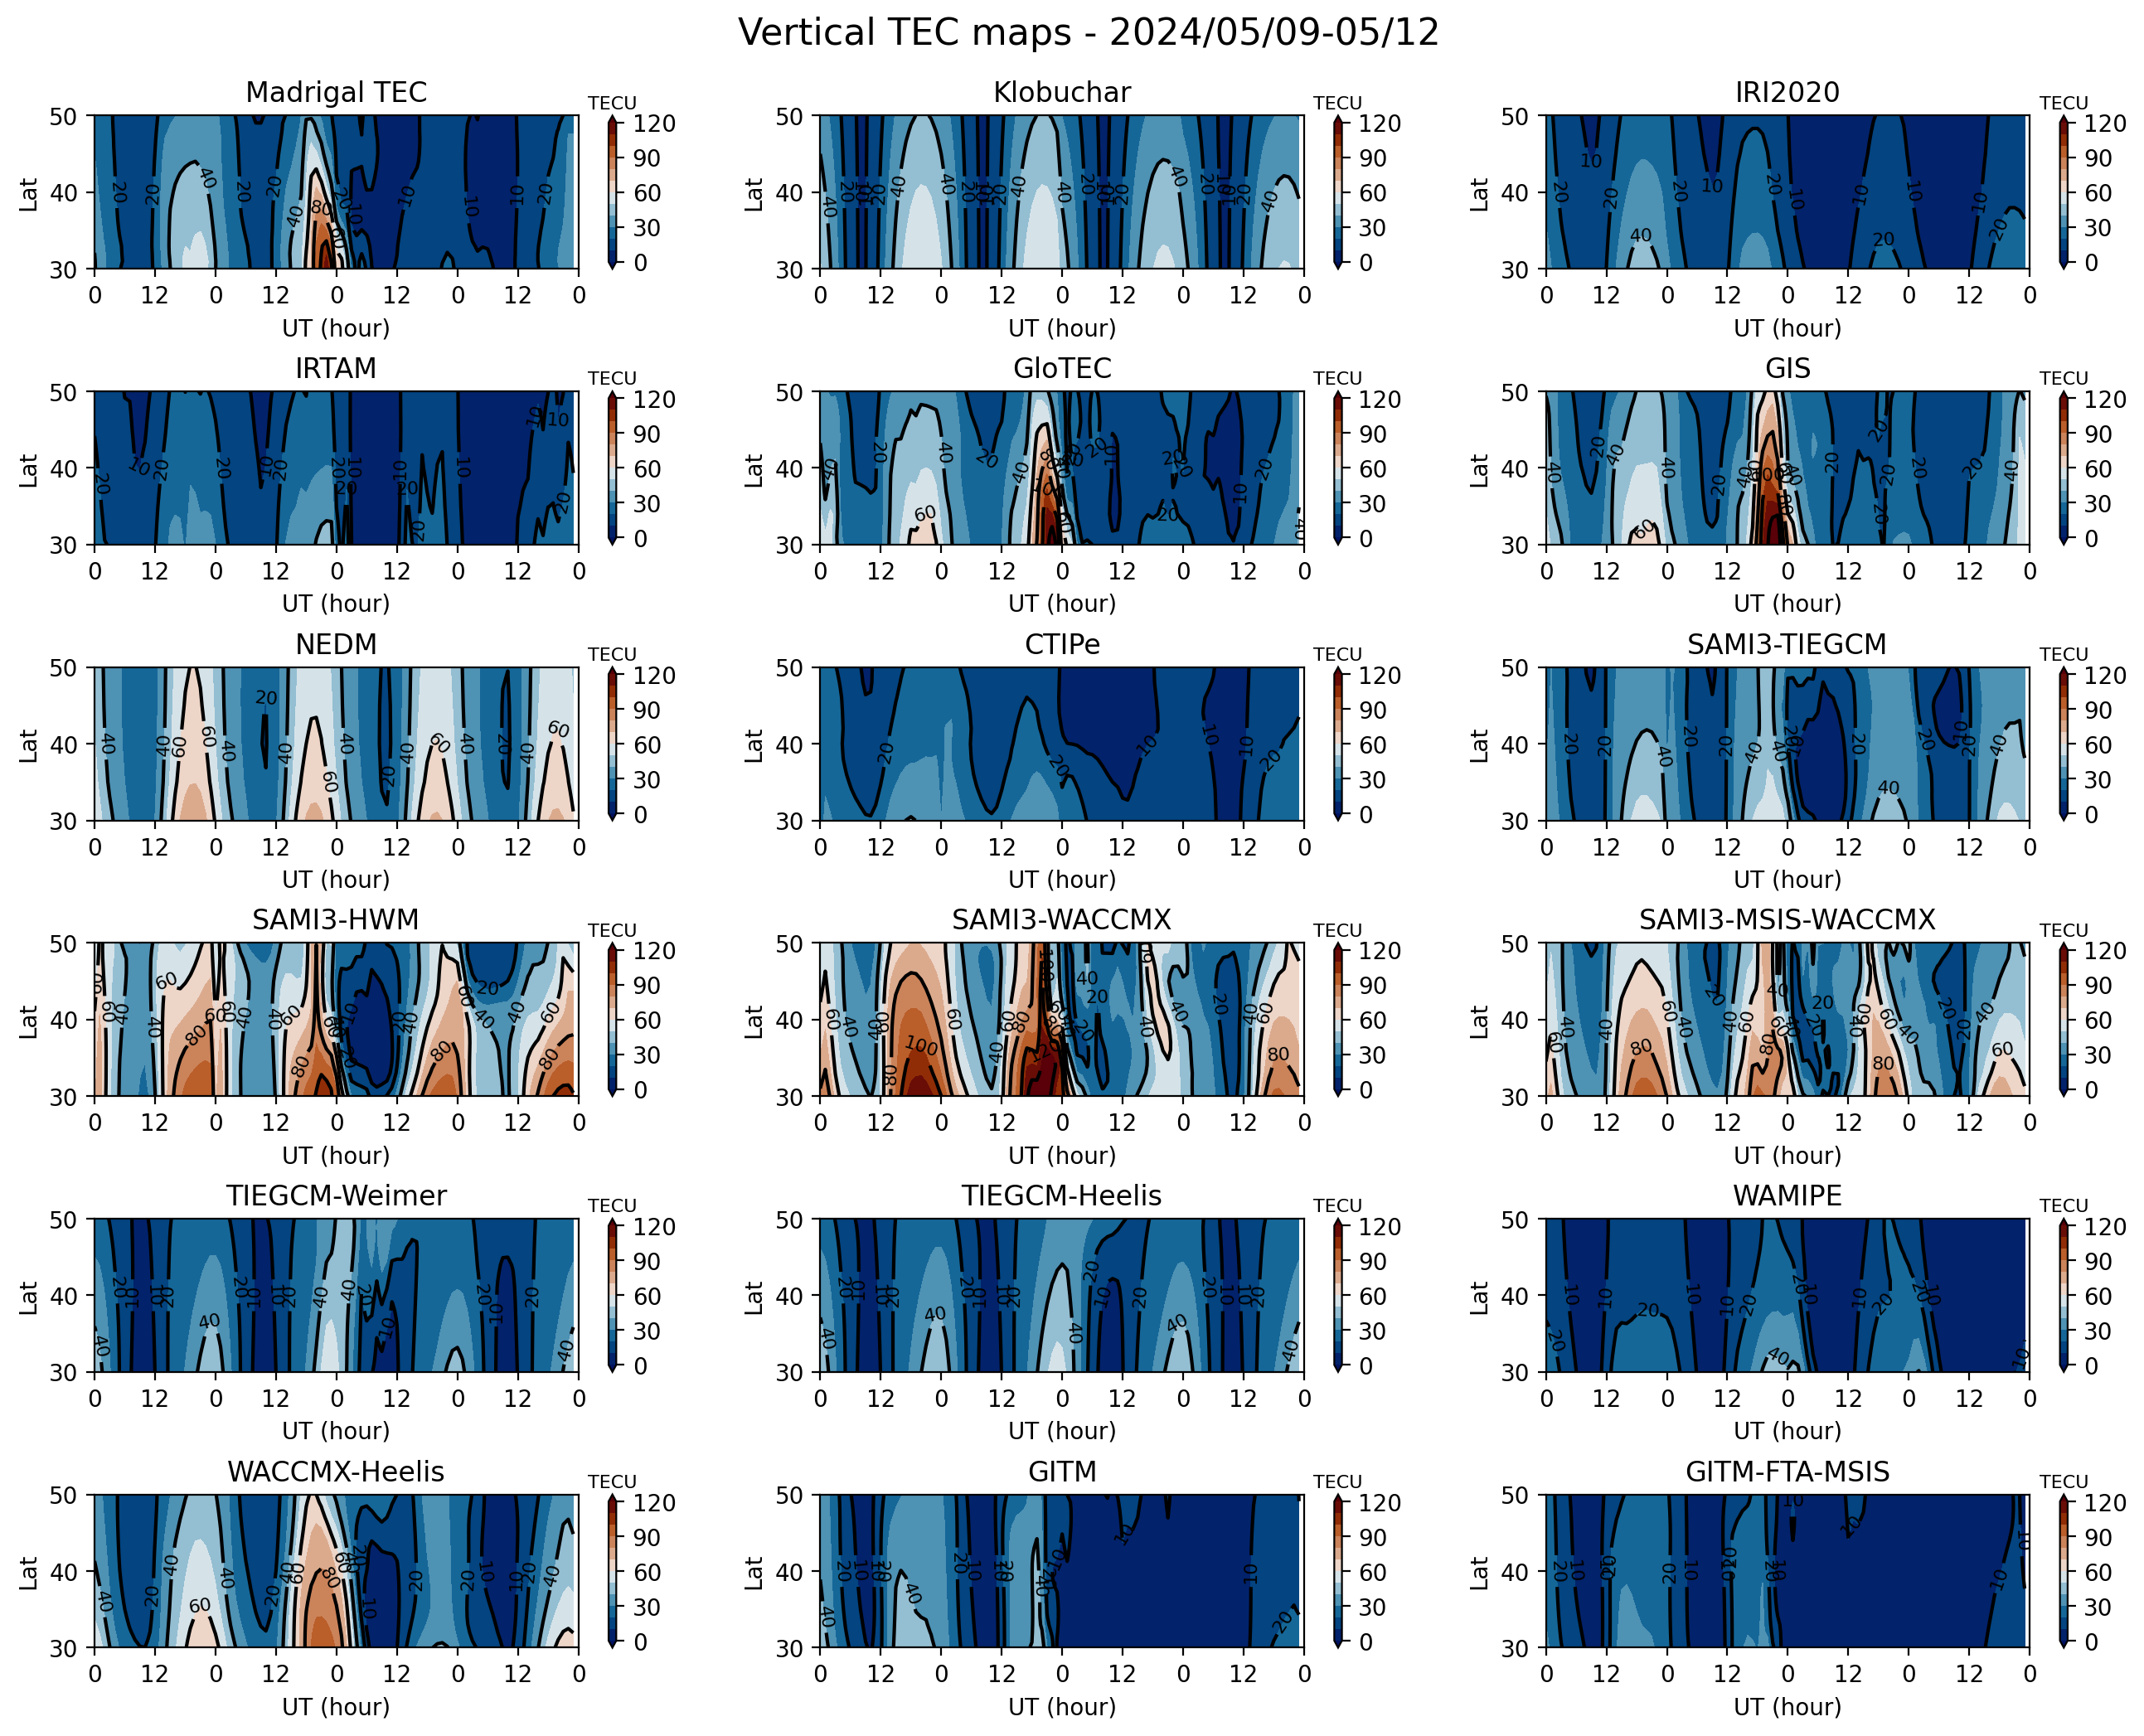

In [10]:

models=['MadTEC','Klobuchar','IRI2020','IRTAM','GloTEC','GIS','NEDM','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX','SAMI3-MSIS-WACCMX',
        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Heelis','GITM','GITM-FTA-MSIS']
plt.style.use('default') 
#gs=fig.add_gridspec(2,3) 
fig,(axs)=plt.subplots(6,3,dpi=200) 
fig.set_size_inches(16, 12) 
plt.subplots_adjust(hspace = .8) 
level=np.arange(0,130,10)
tec_ref_obs=TEC_UTLAT['MadTEC']
global_data_range = np.nanmax(tec_ref_obs) - np.nanmin(tec_ref_obs)
SSIM_dict = {}

for model, ax in zip(models,axs.ravel()): 
    #cntr1=ax.pcolor(np.arange(0,3*24,1),model_latidx,(TEC_UTLAT[model]-TEC_UTLAT['Madrigal TEC']),vmin=-20,vmax=20,cmap=cmap2);
    SSIM_score = ssim(tec_ref_obs, TEC_UTLAT[model],data_range=global_data_range)
    SSIM_dict[model] = SSIM_score
    cntr1=ax.contourf(np.arange(0,4*24,1),model_latidx, TEC_UTLAT[model],levels=level,cmap=cmap2,extend='both'); #ccc=ax.contour(x,y,err1,levels=[-50,-25, 0, 25, 50],colors='black') 
    ccc=ax.contour(np.arange(0,4*24,1),model_latidx, TEC_UTLAT[model],levels=[ 0,10,20,40,60,80,100,120],colors='black'); 
    plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'black')
    if model=='MadTEC':
        ax.set_title(f'Madrigal TEC') 
    else:
        ax.set_title(f'{model}') 
    #75-125W 
    clb=fig.colorbar(cntr1,ax=ax,ticks=np.arange(0,130,30)) 
    ax.set_xticks(np.arange(0,4*24+1,12)) 
    ax.set_xticklabels(np.mod(np.arange(0,4*24+1,12),24)) 
    ax.set_ylabel('Lat') 
    ax.set_xlabel('UT (hour)') 
    clb.ax.set_title('TECU', fontsize=8)
fig.suptitle(f'Vertical TEC maps - 2024/05/09-05/12', fontsize=16, y=0.93)
#axs.ravel()[-1].axis('off') 
plt.show()

# TEC gradient maps as a function of UT and latitude

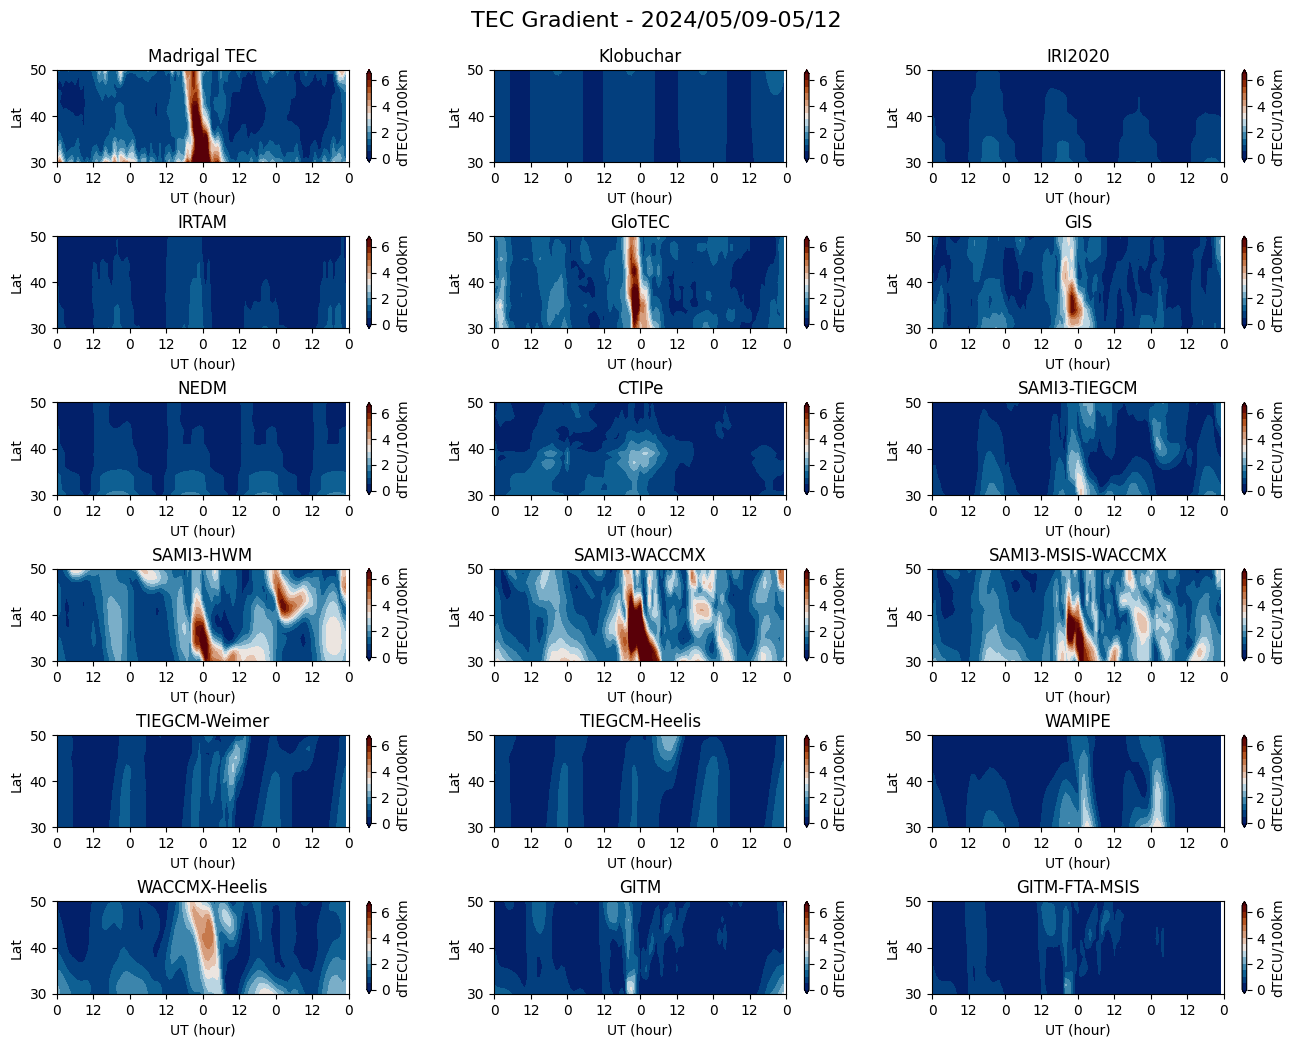

In [11]:
data=np.load(f'TEC_gradient_UTLAT_map.npz',allow_pickle=True)
#RMSE_UTLAT=data['RMSE_UTLAT'].item()
TEC_gradient_UTLAT=data['TEC_gradient_UTLAT'].item()

model_latidx=data['model_latidx']
#models=['MadTEC','Klobuchar','IRI2020','GloTEC','GIS','NEDM','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX',
#        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','CTIPe','WACCMX-Weimer','WACCMX-Heelis']
plt.style.use('default')
            #gs=fig.add_gridspec(2,3)
fig,(axs)=plt.subplots(6,3,dpi=100)
fig.set_size_inches(16, 12)
plt.subplots_adjust(hspace = .8)
level=np.arange(0,7,.5)

#ref=TEC_gradient_UTLAT['MadTEC']
for model, ax in zip(models,axs.ravel()):
    #cntr1=ax.pcolor(np.arange(0,3*24,1),model_latidx,(TEC_UTLAT[model]-TEC_UTLAT['Madrigal TEC']),vmin=-20,vmax=20,cmap=cmap2);
    cntr1=ax.contourf(np.arange(0,4*24,1),model_latidx, (TEC_gradient_UTLAT[model]),levels=level,cmap=cmap2,extend='both');
    #ccc=ax.contour(x,y,err1,levels=[-50,-25, 0, 25, 50],colors='black')
    #ccc=ax.contour(np.arange(0,4*24,1),model_latidx, TEC_gradient_UTLAT[model],levels=np.arange(0,12,2),colors='gray');
    #plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'black')
    if model=='MadTEC':
        ax.set_title(f'Madrigal TEC') #75-125W
    else:
        ax.set_title(f'{model}') #75-125W
    clb=fig.colorbar(cntr1,ax=ax,ticks=np.arange(0,7,2))
    ax.set_xticks(np.arange(0,4*24+1,12))
    ax.set_xticklabels(np.mod(np.arange(0,4*24+1,12),24))
    ax.set_ylabel('Lat')
    ax.set_xlabel('UT (hour)')

#cbar_ax = fig.add_axes([0.92, 0.25, 0.01, 0.5])  # [left, bottom, width, height]
#clb = fig.colorbar(cntr1, cax=cbar_ax, ticks=np.arange(0, 6, 1))
    clb.ax.set_ylabel('dTECU/100km', fontsize=10)

for ax in axs.ravel()[len(models):]:
    ax.axis('off')

fig.suptitle(f'TEC Gradient - 2024/05/09-05/12', fontsize=16, y=0.93)

plt.show()

# TEC gradient RMSE maps

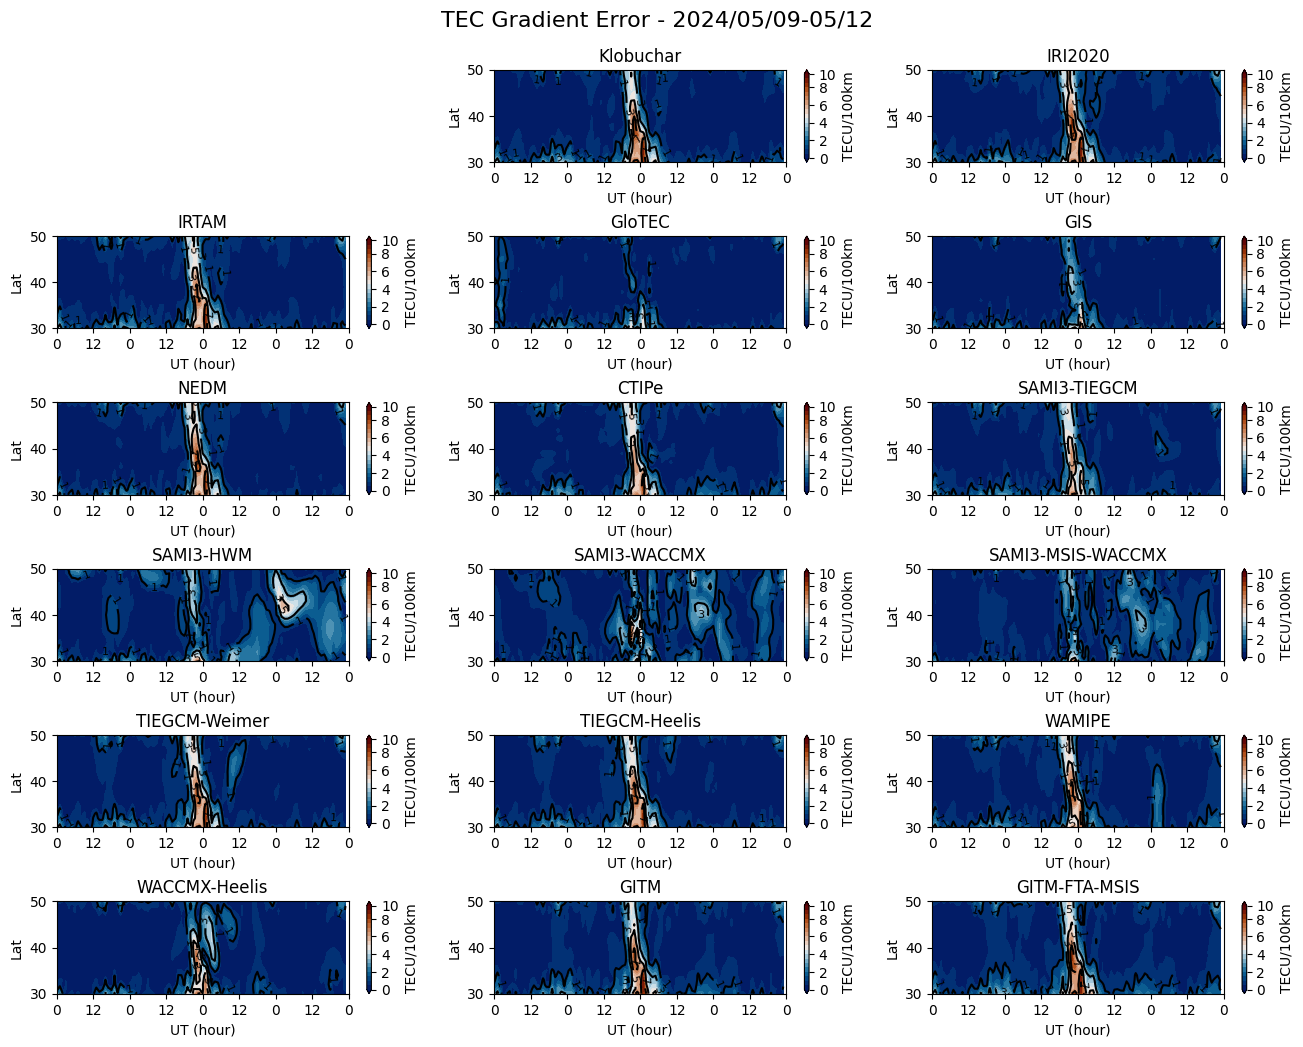

In [13]:
cmap2=cm.vik
#models=['MadTEC','Klobuchar','IRI2020','IRTAM','GloTEC','GIS','NEDM','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX',
#        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Heelis','GITM','GITM-FTA-MSIS']
#for doy in np.arange(131,133)
data=np.load(f'TEC_gradient_UTLAT_map.npz',allow_pickle=True)
#RMSE_UTLAT=data['RMSE_UTLAT'].item()
TEC_gradient_UTLAT=data['TEC_gradient_UTLAT'].item()

model_latidx=data['model_latidx']
#models=['MadTEC','Klobuchar','IRI2020','GloTEC','GIS','NEDM','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX',
#        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','CTIPe','WACCMX-Weimer','WACCMX-Heelis']
plt.style.use('default')
            #gs=fig.add_gridspec(2,3)
fig,(axs)=plt.subplots(6,3,dpi=100)
fig.set_size_inches(16, 12)
plt.subplots_adjust(hspace = .8)
level=np.arange(0,10,.5)

#ref=TEC_gradient_UTLAT['MadTEC']
for model, ax in zip(models[1:],axs.ravel()[1:]):
    #cntr1=ax.pcolor(np.arange(0,3*24,1),model_latidx,(TEC_UTLAT[model]-TEC_UTLAT['Madrigal TEC']),vmin=-20,vmax=20,cmap=cmap2);
    cntr1=ax.contourf(np.arange(0,4*24,1),model_latidx, np.abs(TEC_gradient_UTLAT[model]-TEC_gradient_UTLAT['MadTEC']),levels=level,cmap=cmap2,extend='both');
    ccc=ax.contour(np.arange(0,4*24,1),model_latidx,np.abs(TEC_gradient_UTLAT[model]-TEC_gradient_UTLAT['MadTEC']),levels=[1,3,5,7,9],colors='black');
    plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'black')

    #ccc=ax.contour(x,y,err1,levels=[-50,-25, 0, 25, 50],colors='black')
    #ccc=ax.contour(np.arange(0,4*24,1),model_latidx, TEC_gradient_UTLAT[model],levels=np.arange(0,12,2),colors='gray');
    #plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'black')
    if model=='MadTEC':
        ax.set_title(f'Madrigal TEC') #75-125W
    else:
        ax.set_title(f'{model}') #75-125W
    clb=fig.colorbar(cntr1,ax=ax,ticks=np.arange(0,11,2))
    ax.set_xticks(np.arange(0,4*24+1,12))
    ax.set_xticklabels(np.mod(np.arange(0,4*24+1,12),24))
    ax.set_ylabel('Lat')
    ax.set_xlabel('UT (hour)')

#cbar_ax = fig.add_axes([0.92, 0.25, 0.01, 0.5])  # [left, bottom, width, height]
#clb = fig.colorbar(cntr1, cax=cbar_ax, ticks=np.arange(0, 6, 1))
    clb.ax.set_ylabel('TECU/100km', fontsize=10)

for ax in axs.ravel()[:1]:
    ax.axis('off')
#axs.ravel()[-1].axis('off')

fig.suptitle(f'TEC Gradient Error - 2024/05/09-05/12', fontsize=16, y=0.93)
plt.show()

# Relative TEC change

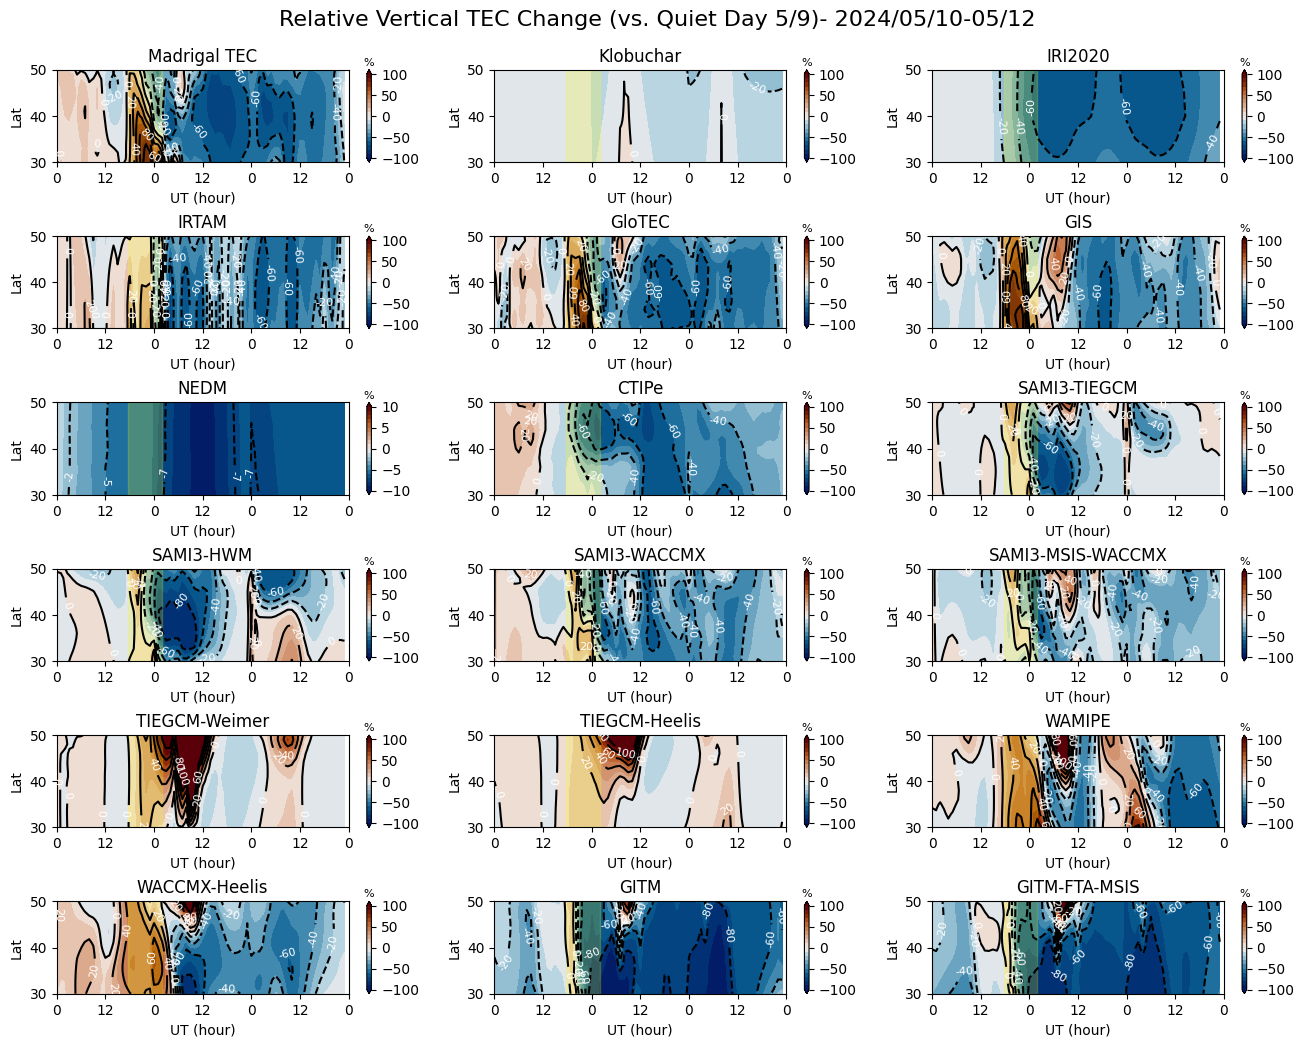

In [15]:
main_ph = 26 + 24-24
quiet_ph = 24 + 17 + 40 / 60-24

models=['MadTEC','Klobuchar','IRI2020','IRTAM','GloTEC','GIS','NEDM','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX','SAMI3-MSIS-WACCMX',
        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Heelis','GITM','GITM-FTA-MSIS']
model_latidx=np.arange(30,51,1)

#cmap2=cm.roma_r #models=['Madrigal TEC','Klobuchar','IRI2020','GloTEC','GIS','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','TIEGCM-Heelis']
#models=['MadTEC','Klobuchar','IRI2020','GIS','GloTEC','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Weimer'] 
#models=['MadTEC','Klobuchar','IRI2020','GloTEC','GIS','NEDM','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX', 'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','CTIPe','WACCMX-Weimer','WACCMX-Heelis'] 
plt.style.use('default') 
#gs=fig.add_gridspec(2,3) 
fig,(axs)=plt.subplots(6,3,dpi=100) 
fig.set_size_inches(16, 12) 
plt.subplots_adjust(hspace = .8) 
tec_ref_obs=np.tile(TEC_UTLAT['MadTEC'][:,:24], (1, 4))
tec_change_obs= (TEC_UTLAT['MadTEC']-tec_ref_obs)/tec_ref_obs*100




for midx,(model, ax) in enumerate(zip(models,axs.ravel())): 
    #cntr1=ax.pcolor(np.arange(0,3*24,1),model_latidx,(TEC_UTLAT[model]-TEC_UTLAT['Madrigal TEC']),vmin=-20,vmax=20,cmap=cmap2);
    #TEC_UTLAT[model].shape
    if model  == 'NEDM':
        level=np.arange(-10,11,1)
        level2=np.arange(-10,11,2.5) 
    else:
        level=np.arange(-100,110,10)
        level2=np.arange(-100,110,20)

    tec_ref=np.tile(TEC_UTLAT[model][:,:24], (1, 4))
    tec_change= (TEC_UTLAT[model]-tec_ref)/tec_ref*100
  
    #x = gtec1.flatten()
    #    y = gtec2.flatten()
    #    mask = (~np.isnan(x)) & (~np.isnan(y)) #& (~np.isinf(x)) & (~np.isinf(y))
 

    cntr1=ax.contourf(np.arange(0,3*24,1),model_latidx, tec_change[:,24:],levels=level,cmap=cmap2,extend='both'); #ccc=ax.contour(x,y,err1,levels=[-50,-25, 0, 25, 50],colors='black') 
    ccc=ax.contour(np.arange(0,3*24,1),model_latidx, tec_change[:,24:],levels=level2 ,colors='black'); 
    plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'white') 
    if model=='MadTEC':
        ax.set_title(f'Madrigal TEC') 
    else:
        ax.set_title(f'{model}') 
    ax.axvspan(quiet_ph, main_ph, color='yellow', alpha=0.2)
  
    #75-125W
    if model == 'NEDM':
        clb=fig.colorbar(cntr1,ax=ax,ticks=np.arange(-10,11,5))
    else:
        clb=fig.colorbar(cntr1,ax=ax,ticks=np.arange(-100,110,50)) 
    ax.set_xticks(np.arange(0,3*24+1,12)) 
    ax.set_xticklabels(np.mod(np.arange(0,3*24+1,12),24)) 
    ax.set_ylabel('Lat') 
    ax.set_xlabel('UT (hour)')
    #ax.set_xlim([0, 24])
    clb.ax.set_title('%', fontsize=8)
fig.suptitle(f'Relative Vertical TEC Change (vs. Quiet Day 5/9)- 2024/05/10-05/12', fontsize=16, y=0.93)

#axs.ravel()[-1].axis('off') 
plt.show()

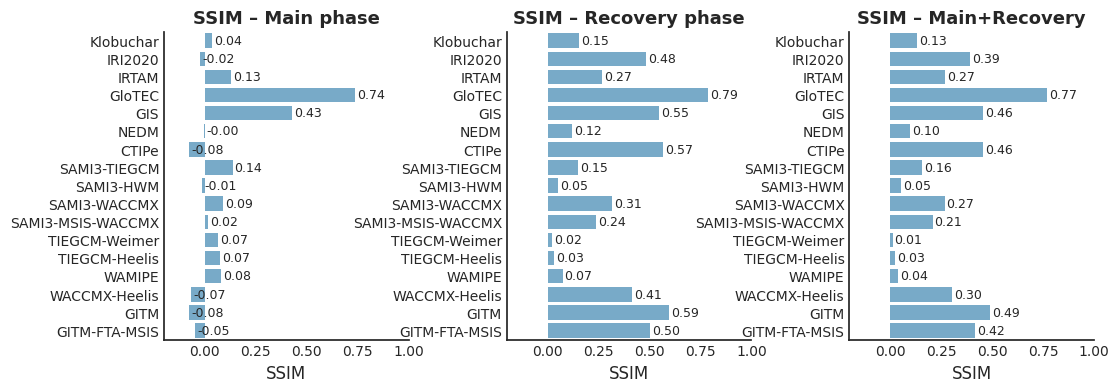

/tmp/ipykernel_28567/3727177077.py:93: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_28567/3727177077.py:93: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


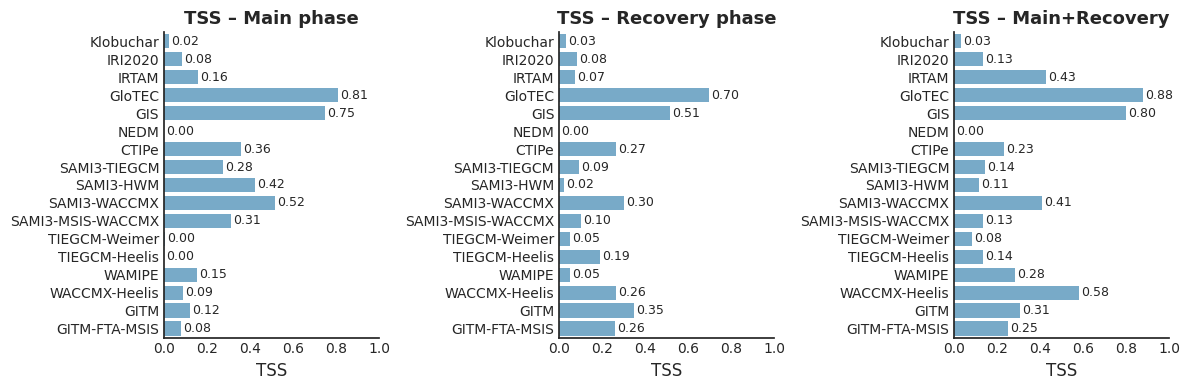

In [16]:
combined_df = pd.read_csv('TEC_anomaly_scores.csv', header=[0, 1], index_col=0)
combined_df



# Example inputs: each dict has {model: [main, recovery, all]}
models = list(SSIM_dict.keys())
phases = ['Main phase', 'Recovery phase', 'Main+Recovery']

# Convert dicts to DataFrames
SSIM_df = combined_df['SSIM']
TSS_df = combined_df['TSS']

# Drop the first model if needed (like Klobuchar)
SSIM_df = SSIM_df.iloc[1:]
TSS_df = TSS_df.iloc[1:]

# Melt data for Seaborn
SSIM_long = SSIM_df.reset_index().melt(id_vars='index', var_name='Phase', value_name='SSIM')
SSIM_long.rename(columns={'index': 'Model'}, inplace=True)
TSS_long = TSS_df.reset_index().melt(id_vars='index', var_name='Phase', value_name='TSS')
TSS_long.rename(columns={'index': 'Model'}, inplace=True)

# Custom color palettes
custom_colors = sns.color_palette("Blues", 3)
custom_colors_gray = sns.color_palette("Greys", 3)
plt.style.use('seaborn-v0_8-white')

# Create figure: 2 rows (SSIM, TSS), 3 columns (phases)
#fig, axs = plt.subplots(2, 3, figsize=(12, 8), dpi=100)
#fig.subplots_adjust(hspace=0.3, wspace=0.4)
fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=100)
fig.subplots_adjust(hspace=0.3, wspace=0.4)
# === SSIM (top row) ===
for i, phase in enumerate(phases):
    ax = axs[i]
    phase_data = SSIM_long[SSIM_long['Phase'] == phase]
    sns.barplot(
        data=phase_data,
        x='SSIM',
        y='Model',
        color=custom_colors[1],
        ax=ax
    )

    # Annotate bars with values
    for p in ax.patches:
        width = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.text(width + 0.01, y, f"{width:.2f}", va='center', fontsize=9)

    ax.set_xlim(-0.2, 1)
    ax.set_title(f"SSIM – {phase}", fontsize=13, fontweight='bold')
    ax.set_xlabel("SSIM", fontsize=12)
    #if i == 0:
    #ax.set_ylabel("Model", fontsize=12)
    #else:
    ax.set_ylabel("")
    #    ax.set_yticklabels([])
    sns.despine(ax=ax)
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=100)
fig.subplots_adjust(hspace=0.3, wspace=0.4)
# === TSS (bottom row) ===
for i, phase in enumerate(phases):
    ax = axs[i]
    phase_data = TSS_long[TSS_long['Phase'] == phase]

    sns.barplot(
        data=phase_data,
        x='TSS',
        y='Model',
        color=custom_colors[1],
        ax=ax
    )

    for p in ax.patches:
        width = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.text(width + 0.01, y, f"{width:.2f}", va='center', fontsize=9)

    ax.set_xlim(0, 1)
    ax.set_title(f"TSS – {phase}", fontsize=13, fontweight='bold')
    ax.set_xlabel("TSS", fontsize=12)
    #if i == 0:
    #ax.set_ylabel("Model", fontsize=12)
    #else:
    ax.set_ylabel("")
    #    ax.set_yticklabels([])
    sns.despine(ax=ax)

    plt.tight_layout()
plt.show()




# 3D error maps as a function of UT and LAT

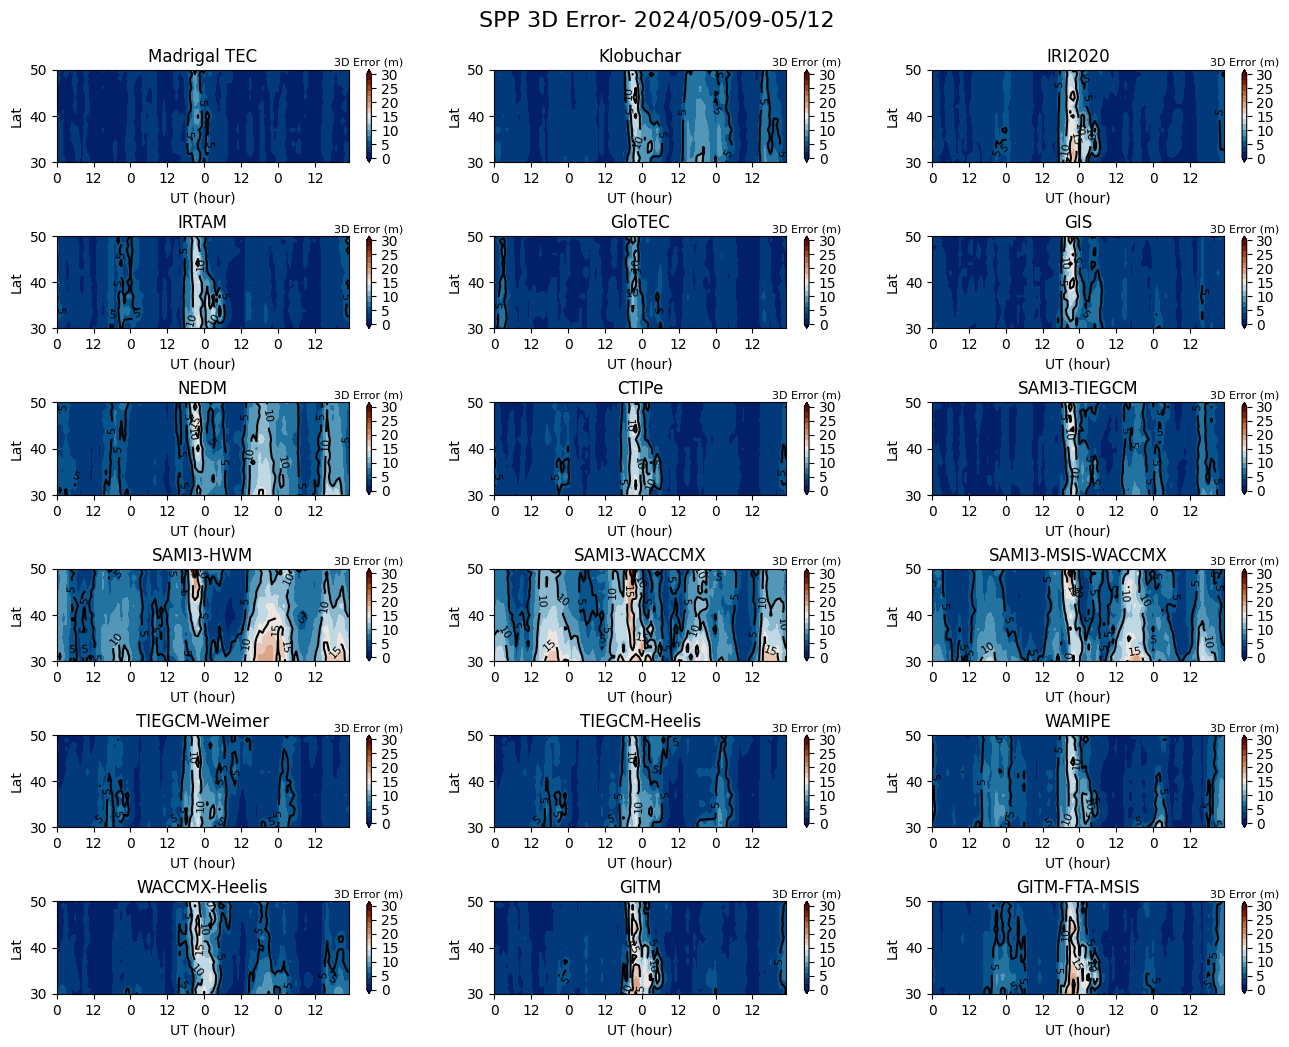

In [17]:
data=np.load(f'ERROR_UTLAT_map_75125W_60min_SPP.npz',allow_pickle=True)


error_type='3D'

ERROR_UTLAT1=data[f'ERROR_{error_type}_UTLAT'].item()

models=['MadTEC','Klobuchar','IRI2020','IRTAM','GloTEC','GIS','NEDM','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX','SAMI3-MSIS-WACCMX',
        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Heelis','GITM','GITM-FTA-MSIS']
model_latidx=np.arange(30,51,1)
#model_latidx=np.arange(25,50,2)
plt.style.use('default')

fig,(axs)=plt.subplots(6,3,dpi=100)
fig.set_size_inches(16, 12)
plt.subplots_adjust(hspace = .8)
if error_type=='3D':
    level=np.arange(0,31,2)
    level2=np.arange(0,31,5)
else:
    level=np.arange(0,21,2)
    level2=np.arange(0,21,5)
for model, ax in zip(models,axs.ravel()):
    #data=np.load(f'ERROR_UTLAT_map_{model}_75125W_60min.npz',allow_pickle=True)
    #ERROR_UTLAT1=data['ERROR_3D_UTLAT']
    #model_latidx=data['model_latidx']
    cntr1=ax.contourf(np.arange(0,4*24,1),model_latidx,ERROR_UTLAT1[model],levels=level,cmap=cmap2, extend='both');
    ccc=ax.contour(np.arange(0,4*24,1),model_latidx,ERROR_UTLAT1[model],levels=[0,5,10,15,20],colors='black');
    plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'black')

    #if model=='SAMI3-HWM':model='SAMI3'
    if model=='MadTEC':
        model='Madrigal TEC'
    ax.set_title(f'{model}')
    clb=fig.colorbar(cntr1,ax=ax,ticks=level2)
    ax.set_xticks(np.arange(0,4*24,12))
    ax.set_xticklabels(np.mod(np.arange(0,(4*24),12),24).astype(int))
    ax.set_ylabel('Lat')
    ax.set_xlabel('UT (hour)')
    clb.ax.set_title(f'{error_type} Error (m)', fontsize=8)
    #ax.set_ylim(30, 50)
fig.suptitle(f'SPP {error_type} Error- 2024/05/09-05/12', fontsize=16, y=0.93)

plt.show()


# 2D error maps as a function of UT and LAT

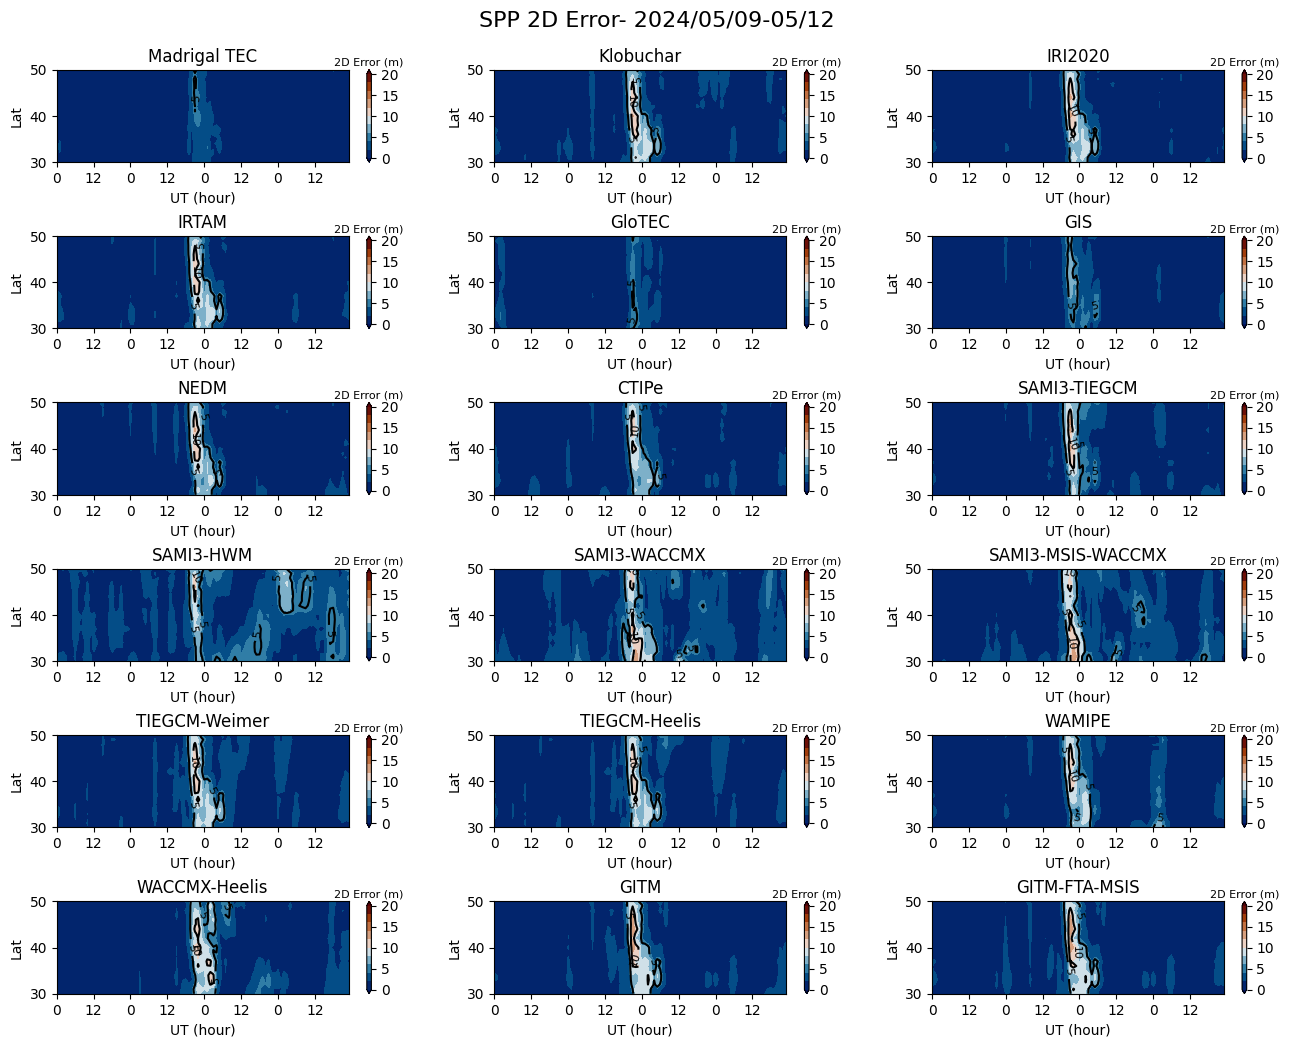

In [19]:
error_type='2D'
ERROR_UTLAT1=data[f'ERROR_{error_type}_UTLAT'].item()
#models = ['Klobuchar' ,'IRI2020', 'GloTEC', 'GIS', 'CTIPe', 'SAMI3-TIEGCM', 'SAMI3-HWM', 'TIEGCM-Heelis']
#models=['MadTEC','Klobuchar','IRI2020','GloTEC','GIS','NEDM','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX',
#        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','CTIPe','WACCMX-Weimer','WACCMX-Heelis']
#cmap2=cm.roma_r

models=['MadTEC','Klobuchar','IRI2020','IRTAM','GloTEC','GIS','NEDM','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX','SAMI3-MSIS-WACCMX',
        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Heelis','GITM','GITM-FTA-MSIS']
model_latidx=np.arange(30,51,1)
#model_latidx=np.arange(25,50,2)
plt.style.use('default')

fig,(axs)=plt.subplots(6,3,dpi=100)
fig.set_size_inches(16, 12)
plt.subplots_adjust(hspace = .8)
if error_type=='3D':
    level=np.arange(0,31,2)
    level2=np.arange(0,31,5)
else:
    level=np.arange(0,21,2)
    level2=np.arange(0,21,5)
for model, ax in zip(models,axs.ravel()):
    #data=np.load(f'ERROR_UTLAT_map_{model}_75125W_60min.npz',allow_pickle=True)
    #ERROR_UTLAT1=data['ERROR_3D_UTLAT']
    #model_latidx=data['model_latidx']
    cntr1=ax.contourf(np.arange(0,4*24,1),model_latidx,ERROR_UTLAT1[model],levels=level,cmap=cmap2, extend='both');
    ccc=ax.contour(np.arange(0,4*24,1),model_latidx,ERROR_UTLAT1[model],levels=[0,5,10,15,20],colors='black');
    plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'black')

    #if model=='SAMI3-HWM':model='SAMI3'
    if model=='MadTEC':
        model='Madrigal TEC'
    ax.set_title(f'{model}')
    clb=fig.colorbar(cntr1,ax=ax,ticks=level2)
    ax.set_xticks(np.arange(0,4*24,12))
    ax.set_xticklabels(np.mod(np.arange(0,(4*24),12),24).astype(int))
    ax.set_ylabel('Lat')
    ax.set_xlabel('UT (hour)')
    clb.ax.set_title(f'{error_type} Error (m)', fontsize=8)
    #ax.set_ylim(30, 50)
fig.suptitle(f'SPP {error_type} Error- 2024/05/09-05/12', fontsize=16, y=0.93)

plt.show()

# Up (East or North) error maps as a function of UT and LAT

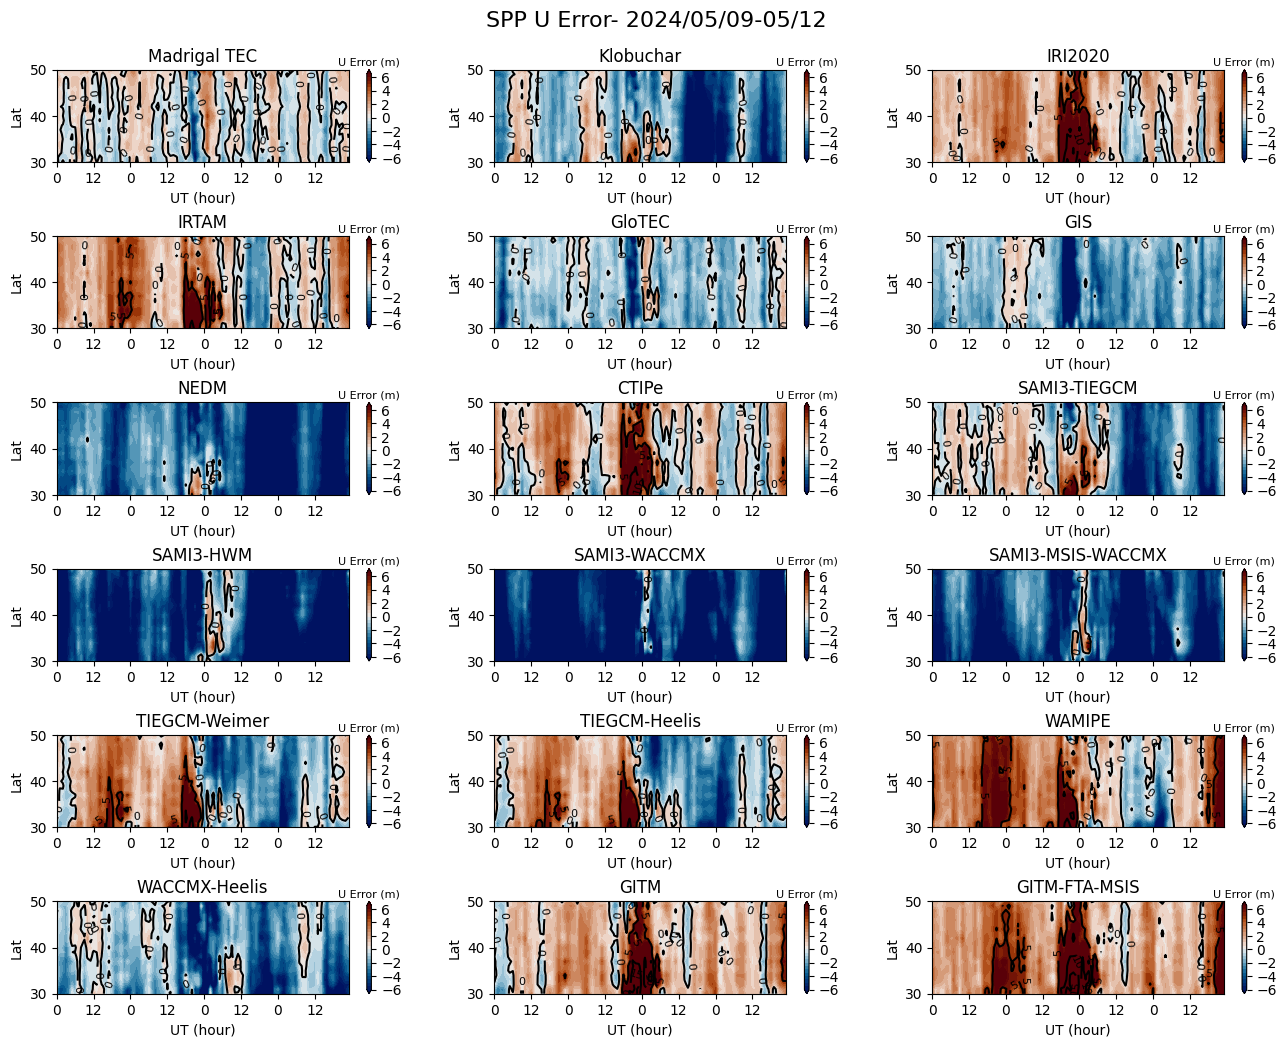

In [22]:
error_type='U' # you can change to E, N, U
ERROR_UTLAT1=data[f'ERROR_{error_type}_UTLAT'].item()

model_latidx=np.arange(30,51,1)
#model_latidx=np.arange(25,50,2)
plt.style.use('default')

fig,(axs)=plt.subplots(6,3,dpi=100)
fig.set_size_inches(16, 12)
plt.subplots_adjust(hspace = .8)
if error_type=='3D':
    level=np.arange(0,31,2)
    level2=np.arange(0,31,5)
elif error_type=='2D':
    level=np.arange(0,21,2)
    level2=np.arange(0,21,5)
else:
    level=np.arange(-6,7,.5)
    level2=np.arange(-6,7,2)
for model, ax in zip(models,axs.ravel()):
    #data=np.load(f'ERROR_UTLAT_map_{model}_75125W_60min.npz',allow_pickle=True)
    #ERROR_UTLAT1=data['ERROR_3D_UTLAT']
    #model_latidx=data['model_latidx']
    cntr1=ax.contourf(np.arange(0,4*24,1),model_latidx,ERROR_UTLAT1[model],levels=level,cmap=cmap2, extend='both');
    ccc=ax.contour(np.arange(0,4*24,1),model_latidx,ERROR_UTLAT1[model],levels=[0,5,10,15,20],colors='black');
    plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'black')

    #if model=='SAMI3-HWM':model='SAMI3'
    if model=='MadTEC':
        model='Madrigal TEC'
    ax.set_title(f'{model}')
    clb=fig.colorbar(cntr1,ax=ax,ticks=level2)
    ax.set_xticks(np.arange(0,4*24,12))
    ax.set_xticklabels(np.mod(np.arange(0,(4*24),12),24).astype(int))
    ax.set_ylabel('Lat')
    ax.set_xlabel('UT (hour)')
    clb.ax.set_title(f'{error_type} Error (m)', fontsize=8)
    #ax.set_ylim(30, 50)
fig.suptitle(f'SPP {error_type} Error- 2024/05/09-05/12', fontsize=16, y=0.93)

plt.show()



In [23]:
# read metric score data
combined_df = pd.read_csv('metric_scores_SPP.csv', header=[0, 1], index_col=0)


# TEC RMSE and TSS

In [26]:
data=np.load(f'g_model_TEC.npz',allow_pickle=True)
model_data=data['model_data'].item()

lon1,lon2=-75,-125
models=['Klobuchar','IRI2020','GloTEC','GIS','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX','SAMI3-MSIS-WACCMX','SAMI3-MSIS-WACCMX',
        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Weimer','WACCMX-Heelis']
model_latidx=np.arange(30,51,1)
#RMSE_UTLAT = {model: np.zeros([len(model_latidx),24*4]) for model in models}
#TEC_UTLAT = {model: np.zeros([len(model_latidx),24*4]) for model in models}
#TEC


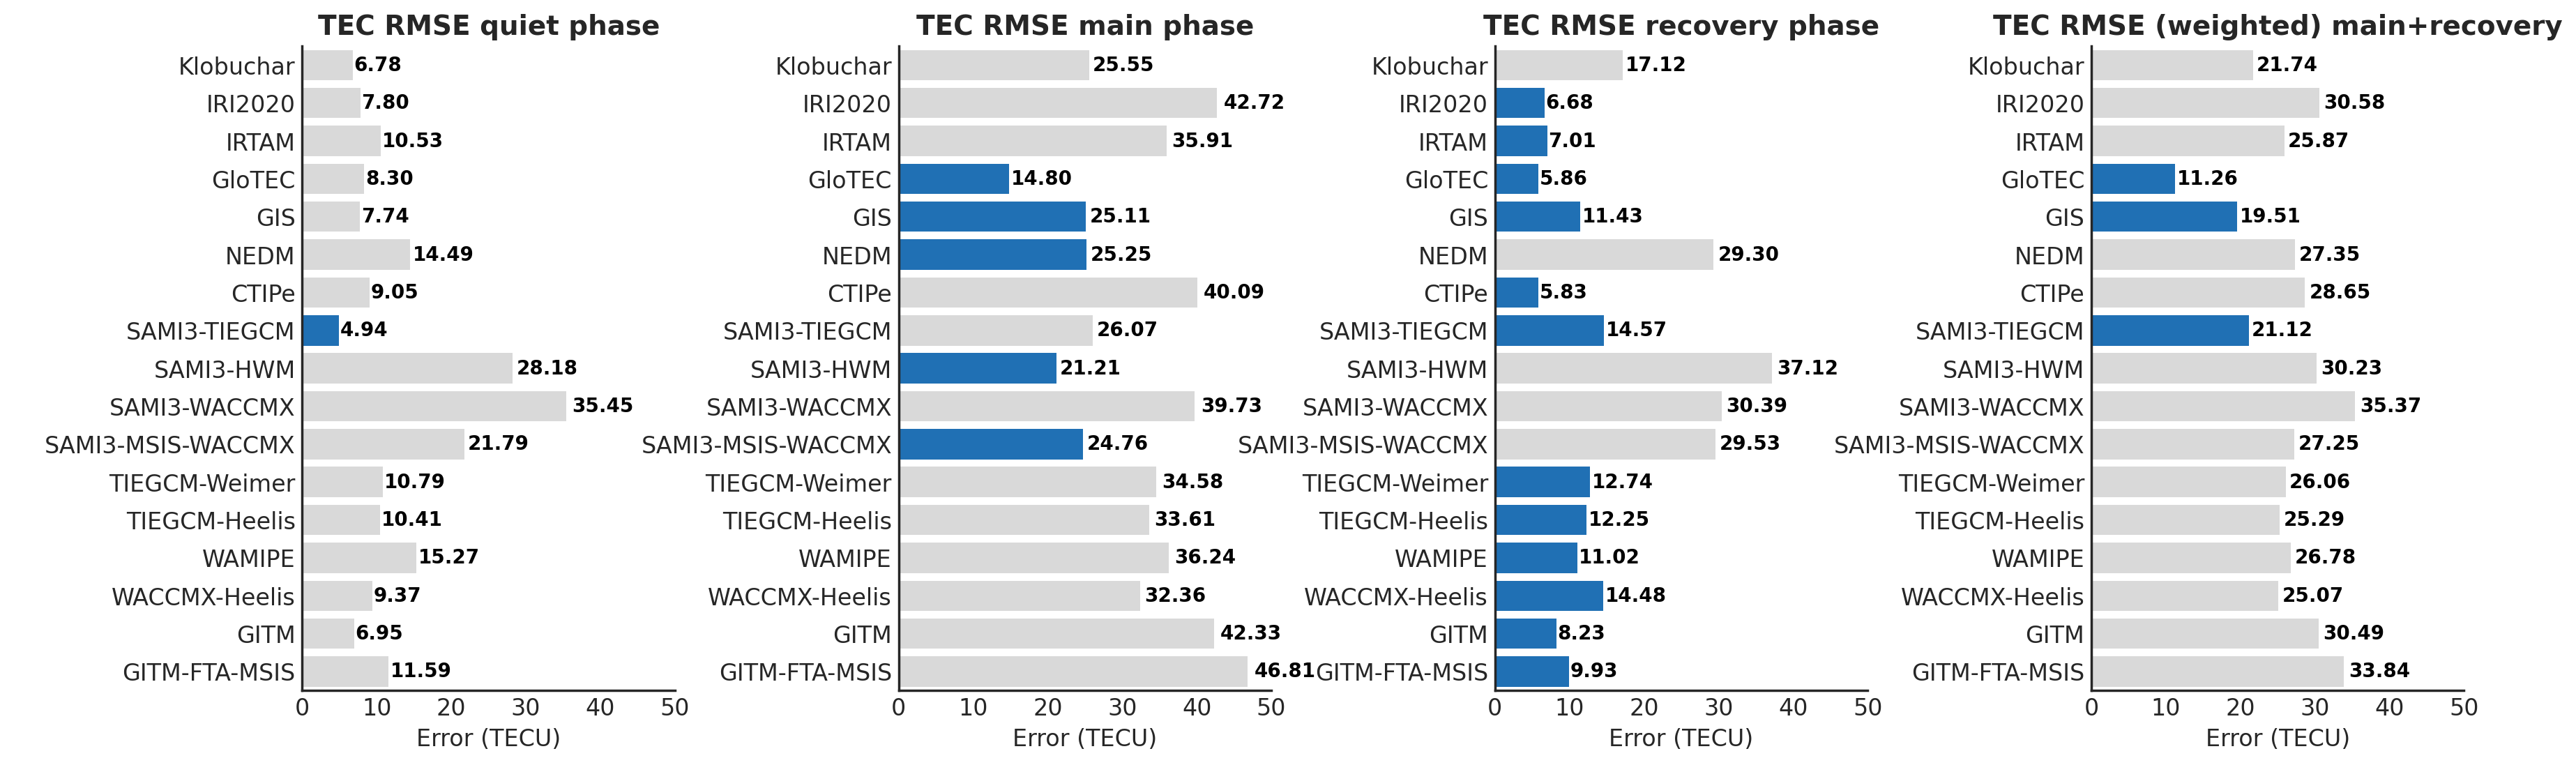

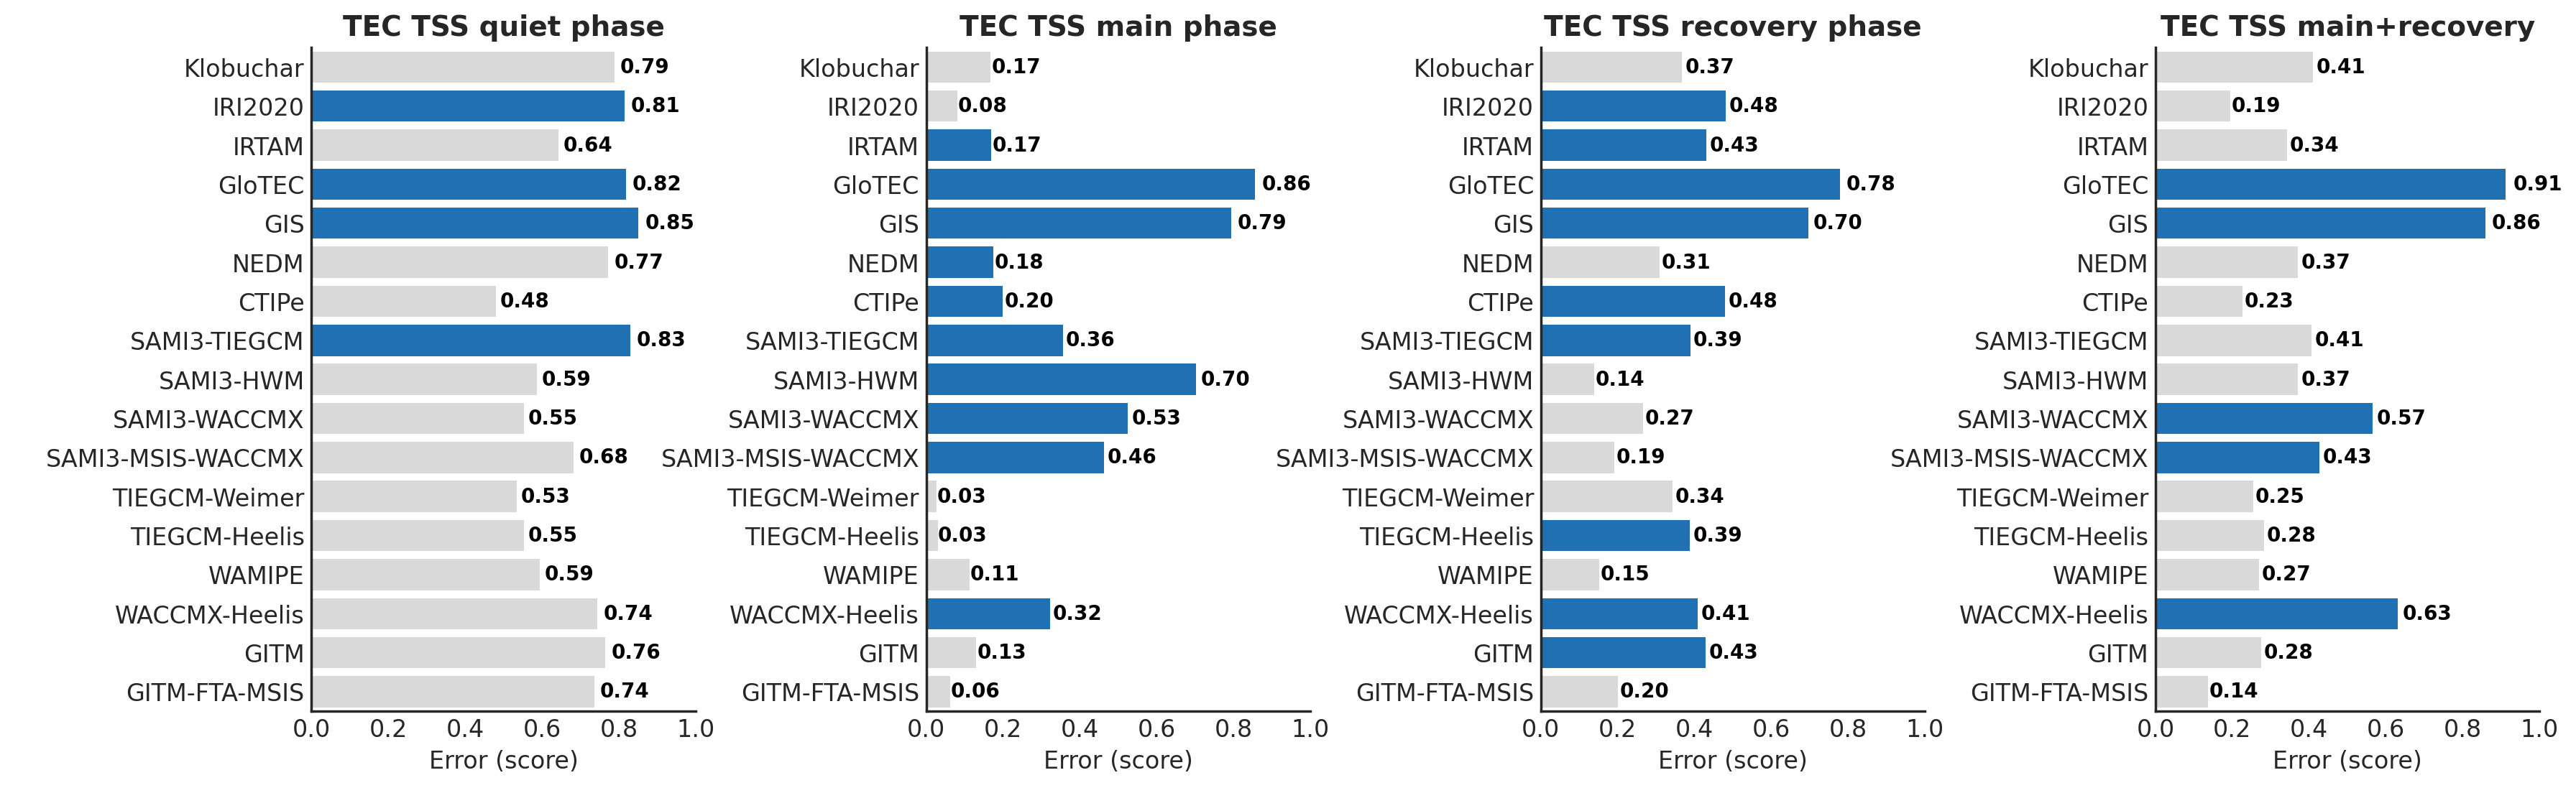

In [27]:
phases=['quiet phase', 'main phase', 'recovery phase','main+recovery']

#phases = ['quiet phase', 'main phase', 'recovery phase']
var = ['TEC RMSE','TEC TSS']
xlabels=['TECU','score']
# Define custom colors for each phase
custom_colors = sns.color_palette("Blues", 3)  # 3 shades of blue
custom_colors1 = sns.color_palette("Greys", 3)
#fig, axs = plt.subplots(2, 4, dpi=200)
#fig.set_size_inches(20, 12)
#fig.subplots_adjust(hspace=0.3, wspace=0.6)
#bar_color = '#1f77b4'  # default blue
plt.style.use('seaborn-v0_8-white') 
#plt.tight_layout()

for idx, var1 in enumerate(var):
    fig, axs = plt.subplots(1, 4, dpi=200)
    fig.set_size_inches(20, 6)
    fig.subplots_adjust(hspace=0.3, wspace=0.6)
    rms_long = combined_df[var1].reset_index().melt(
        id_vars='index', var_name='Phase', value_name=var1
    )
    rms_long.rename(columns={'index': 'Model'}, inplace=True)

    for idx0, phase in enumerate(phases):
        rms_long_filtered = rms_long[rms_long['Phase'] == phase]
        # Exclude the first model
        rms_long_filtered = rms_long_filtered.iloc[1:]
        
        # Plot all bars in blue
        ax = sns.barplot(
            data=rms_long_filtered,
            x=var1,
            y='Model',
            color=custom_colors1[0],
            dodge=False,
            ax=axs[idx0]
        )

        # Get Klobuchar value for this phase
        if "Klobuchar" in rms_long_filtered['Model'].values:
            klob_val = rms_long_filtered.loc[
                rms_long_filtered['Model'] == 'Klobuchar', var1
            ].iloc[0]

            # Highlight models with error smaller than Klobuchar
            for p, model, val in zip(ax.patches,
                                     rms_long_filtered['Model'],
                                     rms_long_filtered[var1]):
                
                if (var1=='TEC RMSE') and (val < klob_val):
                    p.set_facecolor(custom_colors[2])
                
                if (var1 == 'TEC TSS') and (val >klob_val):
                    p.set_facecolor(custom_colors[2])

            # Add vertical line at Klobuchar value
            #ax.axvline(x=klob_val, color='red', linestyle='--', linewidth=2, label='Klobuchar model')

        # Add annotations
        for p in ax.patches:
            width = p.get_width()
            y = p.get_y() + p.get_height() / 2
            ax.text(
                width * 1.02, y, f"{width:.2f}",
                ha='left', va='center',
                fontsize=10, color='k', weight='bold'
            )

        #if idx0 == 0:
        #    ax.set_ylabel("Model", fontsize=12)
        #else:
        #    ax.set_ylabel("")
       #     ax.set_yticklabels([])  # hide y-tick labels
                # Set different x-limits for top and bottom rows
        if idx == 0:  # top row TEC RMSE
            ax.set_xlim(0, 50)
        else:         # bottom row TEC TSS
            ax.set_xlim(0, 1)

        
        sns.despine()
        ax.set_xlabel(f"Error ({xlabels[idx]})", fontsize=12)
        ax.set_ylabel(" ", fontsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.tick_params(axis='x', labelsize=12)
        if (idx0==3)&(idx==0):
            ax.set_title(f"{var1} (weighted) {phase}", fontsize=14., fontweight='bold')
        else:ax.set_title(f"{var1} {phase}", fontsize=14., fontweight='bold')

    plt.show()

# RMSE positioning error

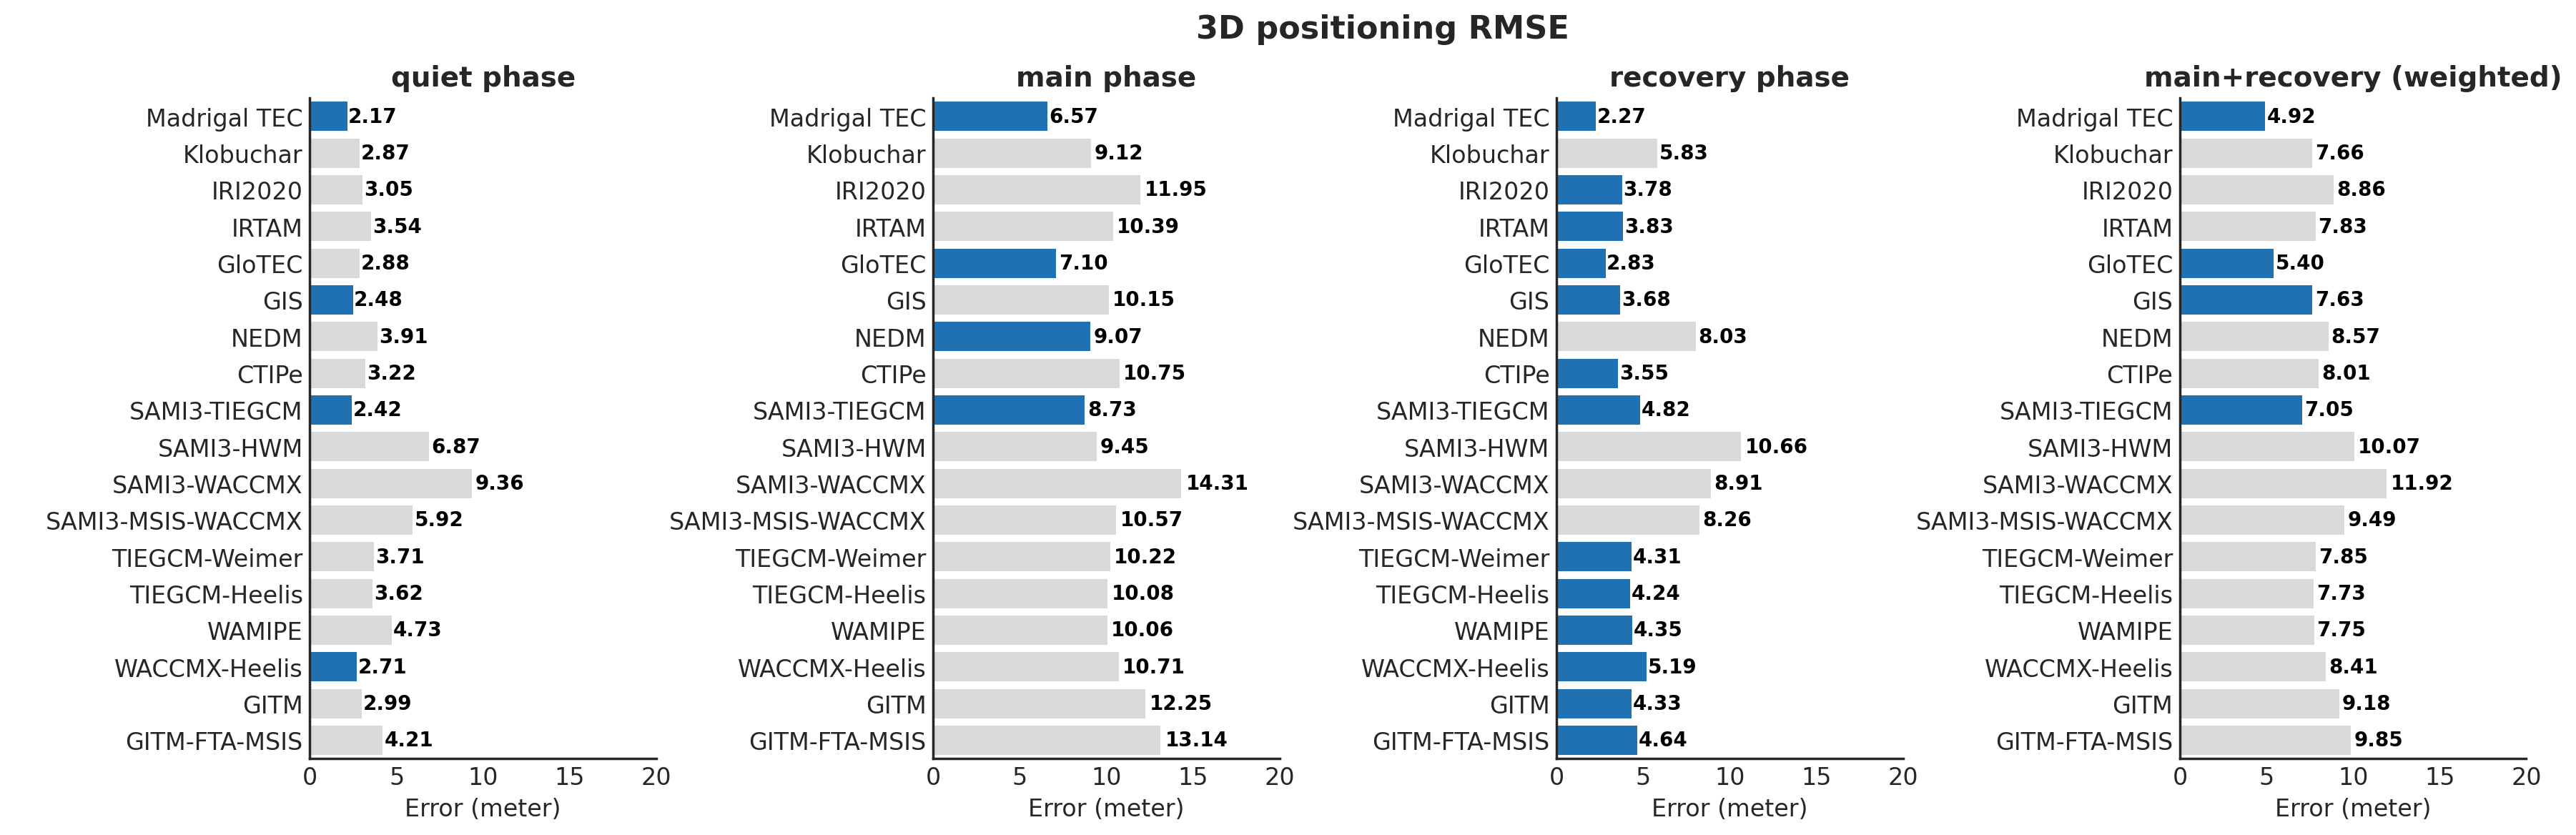

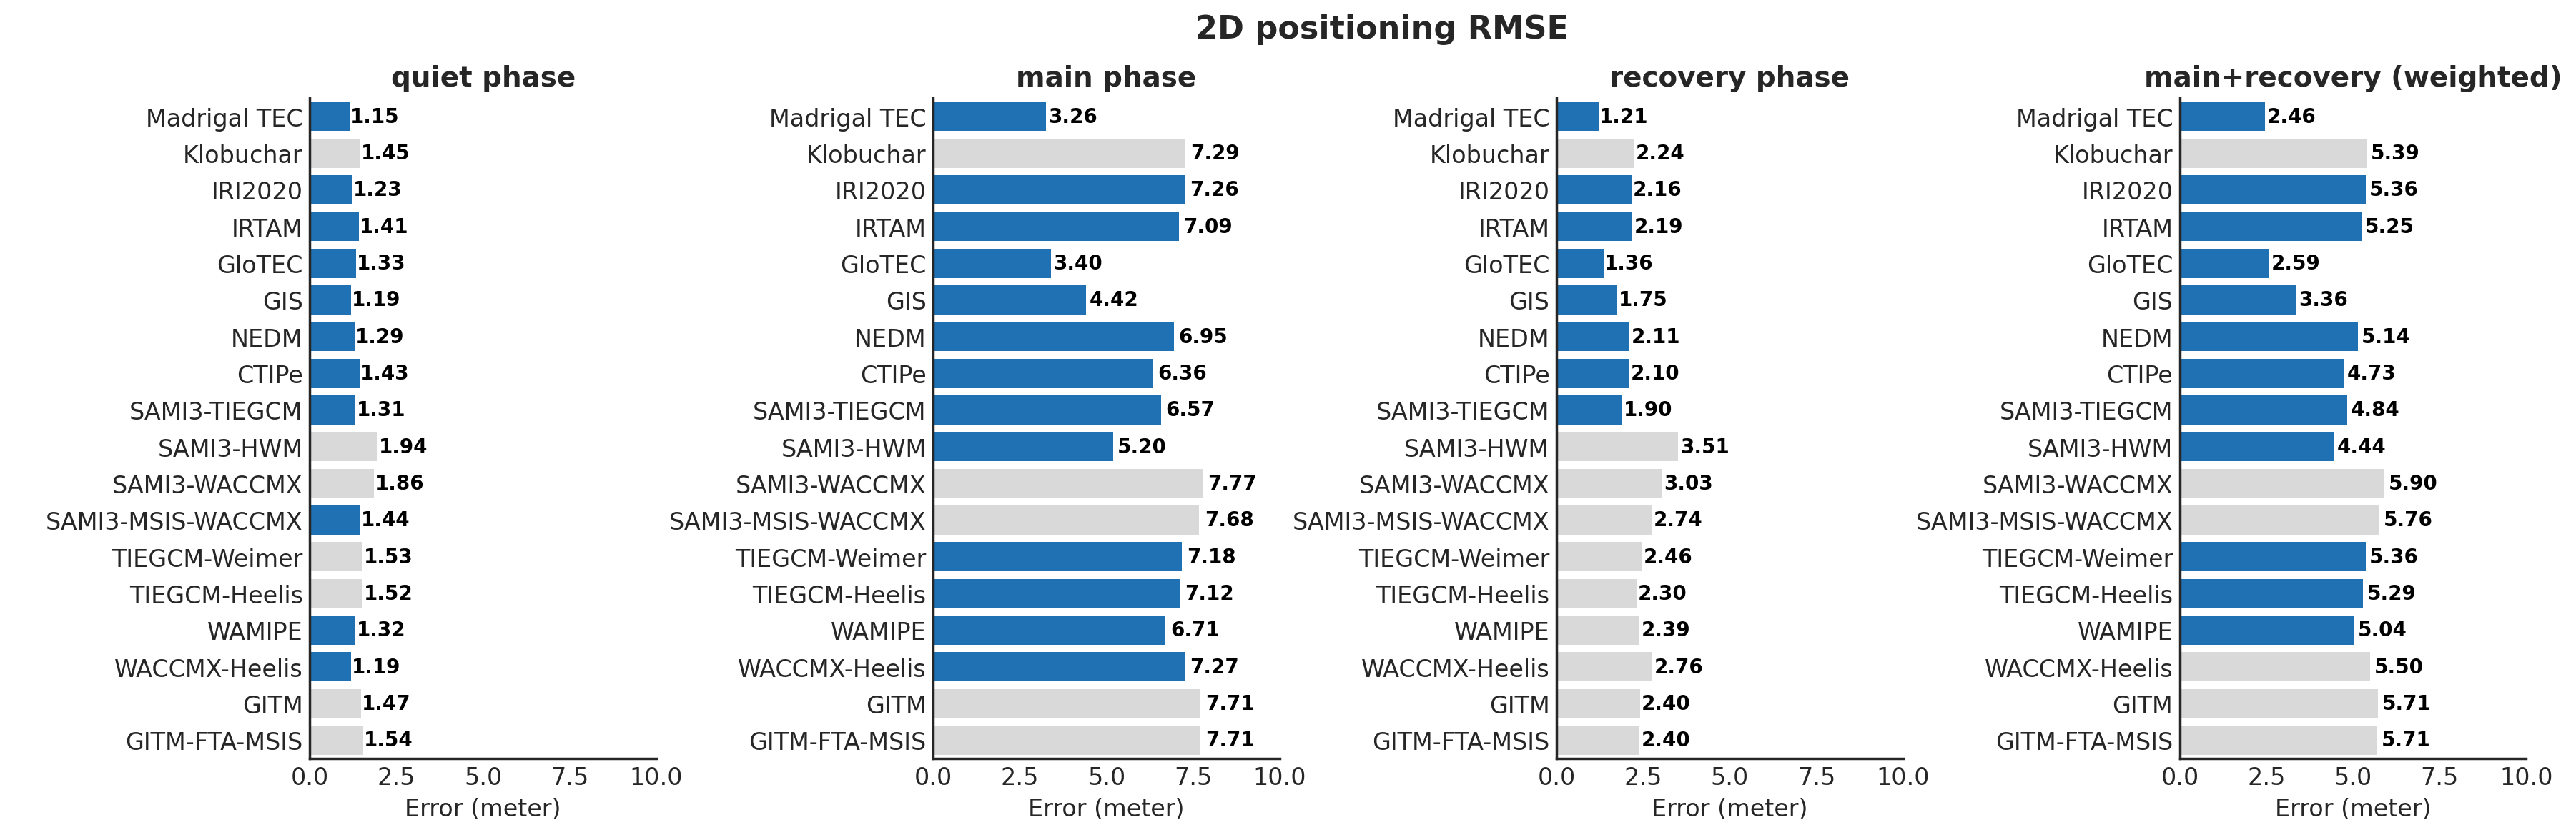

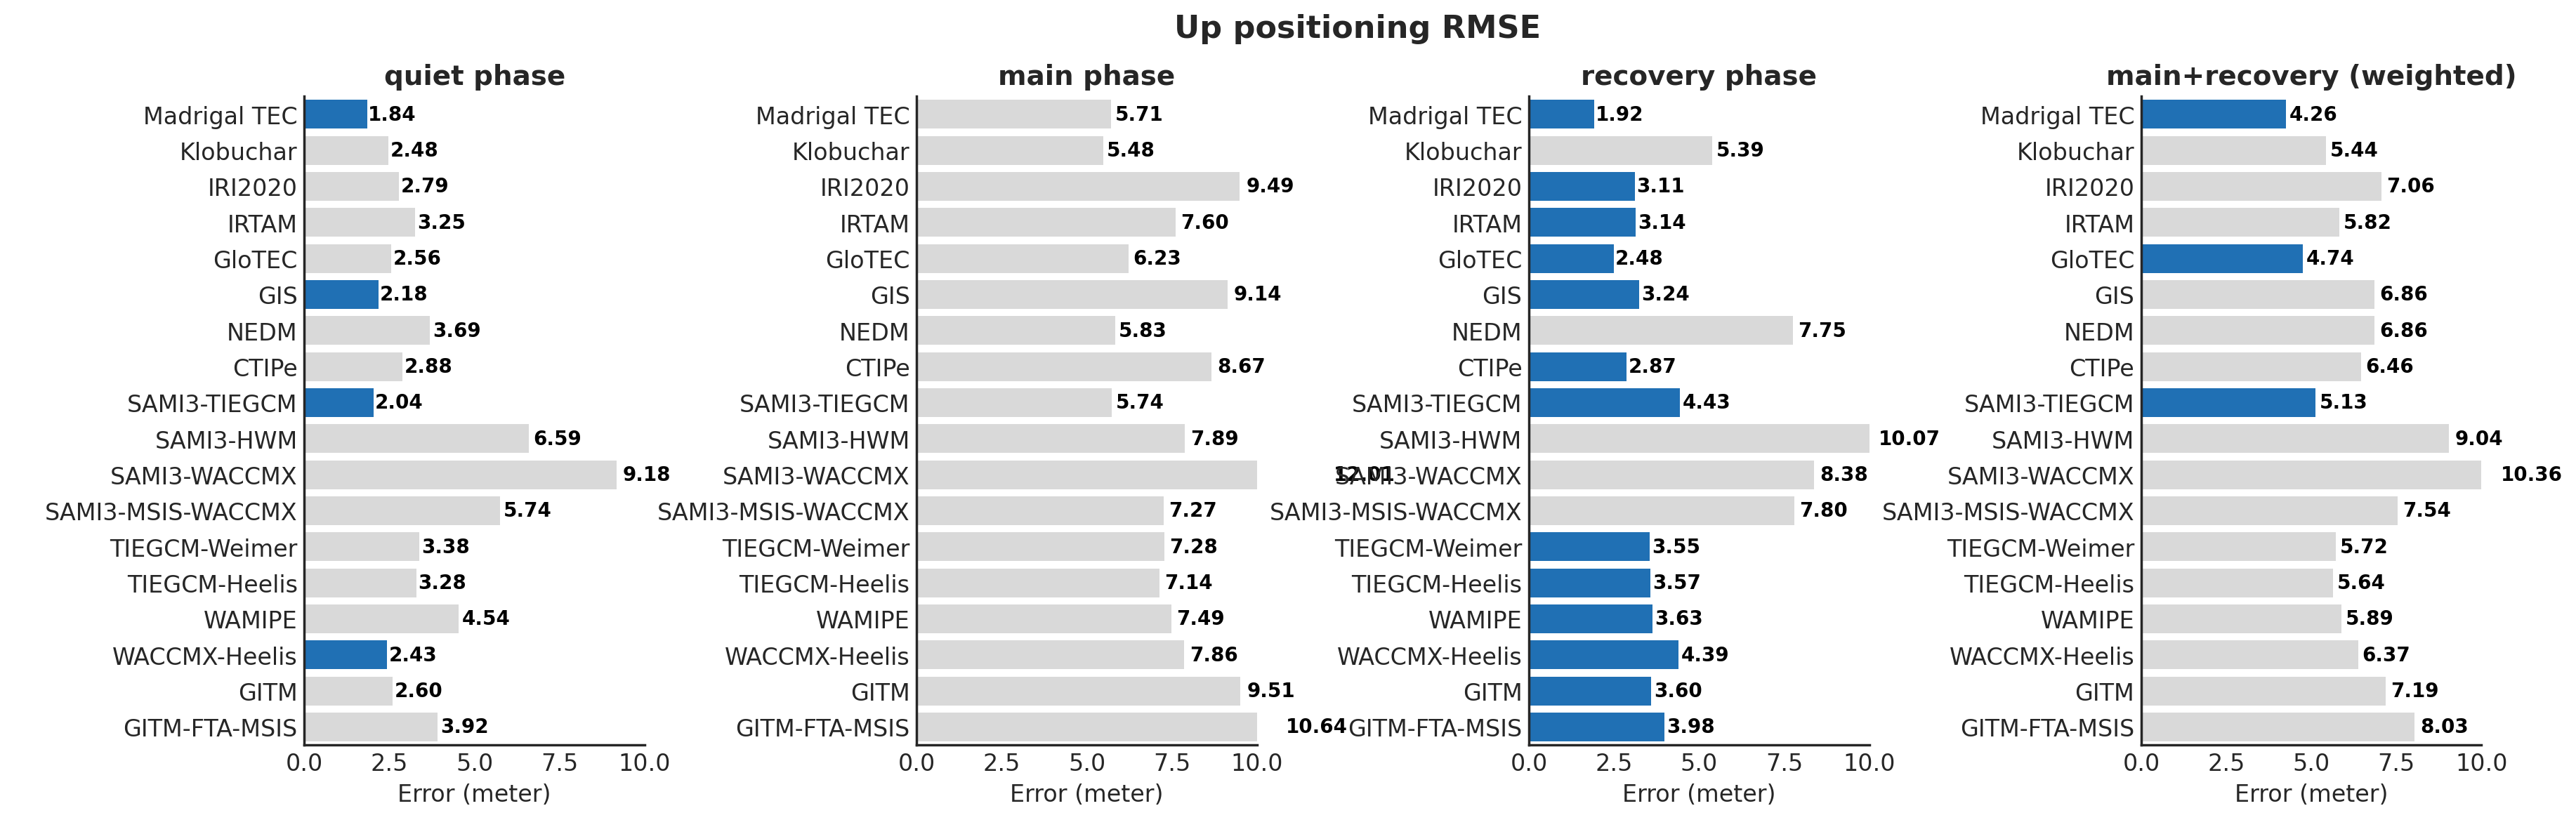

In [29]:
#phases = ['quiet phase', 'main phase', 'recovery phase']
var = ['3D RMSE','2D RMSE','U RMSE']
var2=['3D positioning RMSE','2D positioning RMSE','Up positioning RMSE']
xlabels=['meter','meter','meter']
# Define custom colors for each phase
custom_colors = sns.color_palette("Blues", 3)  # 3 shades of blue
custom_colors1 = sns.color_palette("Greys", 3)
#fig, axs = plt.subplots(2, 4, dpi=200)
#fig.set_size_inches(20, 12)
#fig.subplots_adjust(hspace=0.4, wspace=0.8)
#bar_color = '#1f77b4'  # default blue
plt.style.use('seaborn-v0_8-white') 
#plt.tight_layout()

for idx, var1 in enumerate(var):
    fig, axs = plt.subplots(1, 4, dpi=200)
    fig.set_size_inches(20, 6)
    fig.subplots_adjust(hspace=0.4, wspace=0.8)
    plt.style.use('seaborn-v0_8-white') 
    
    rms_long = combined_df[var1].reset_index().melt(
        id_vars='index', var_name='Phase', value_name=var1
    )
    rms_long.rename(columns={'index': 'Model'}, inplace=True)

    for idx0, phase in enumerate(phases):
        rms_long_filtered = rms_long[rms_long['Phase'] == phase]

        # Plot all bars in blue
        ax = sns.barplot(
            data=rms_long_filtered,
            x=var1,
            y='Model',
            color=custom_colors1[0],
            dodge=False,
            ax=axs[idx0]
        )

        # Get Klobuchar value for this phase
        if "Klobuchar" in rms_long_filtered['Model'].values:
            klob_val = rms_long_filtered.loc[
                rms_long_filtered['Model'] == 'Klobuchar', var1
            ].iloc[0]

            # Highlight models with error smaller than Klobuchar
            for p, model, val in zip(ax.patches,
                                     rms_long_filtered['Model'],
                                     rms_long_filtered[var1]):
                if (var1=='TSS') & (val > klob_val):
                    p.set_facecolor(custom_colors[1])
                elif val < klob_val:
                    p.set_facecolor(custom_colors[2])

            # Add vertical line at Klobuchar value
            #ax.axvline(x=klob_val, color='red', linestyle='--', linewidth=2, label='Klobuchar model')

        # Add annotations
        for p in ax.patches:
            width = p.get_width()
            y = p.get_y() + p.get_height() / 2
            ax.text(
                width * 1.02, y, f"{width:.2f}",
                ha='left', va='center',
                fontsize=10, color='k', weight='bold'
            )
        if idx == 0:  # top row 
            ax.set_xlim(0, 20)
        else:         # bottom row 
            ax.set_xlim(0, 10)

        sns.despine()
        ax.set_xlabel(f"Error ({xlabels[idx]})", fontsize=12)
        ax.set_ylabel(" ", fontsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.tick_params(axis='x', labelsize=12)
        if idx0==3:
            ax.set_title(f"{phase} (weighted)", fontsize=14., fontweight='bold')
        else:
            ax.set_title(f"{phase}", fontsize=14., fontweight='bold')

    fig.text(0.5, 0.95, f'{var2[idx]}', ha='center', fontsize=16, fontweight='bold')  # top row
#fig.text(0.5, 0.48, f'{var2[1]}', ha='center', fontsize=16, fontweight='bold')   # bottom row
    plt.show()